# Project Overview

This notebook implements an end-to-end machine learning pipeline to forecast the 7-day domestic opening revenue of **'Avatar: Fire and Ash'**. It moves beyond basic metadata by engineering advanced market signals. After using a Gradient Boosting Machine (CatBoost) trained on historical data (2000–2025), a prediction was made alongside exploratory analysis to understand the nature of Box Office.

# Objectives

The primary goal of the project is to predict the revenue of the movie 'Avatar: Fire and Ash', to be released on 19 December, 2025. This specific goal leads to certain specifications in this Machine Learning Project:

1. Developing a Machine Learning model suitable for predicting blockbusters and deal with pre-release data.
2. Picking features that will capture the details that drive early box office revenue.
3. Comparing and contrasting the performance of multiple ML models and discuss their nature.

# Project Architecture

![Project Architecture](images/project_architecture.jpg)

## Project Blueprint and Data Extraction

The goal was clear, but the path carried many challenges - the first of them being Data Extraction.

TMDB and BoxOfficeMojo were found to be two of the richest sources for data collection. Modalities like API call and scraping were deployed across the board to farm desired features. For the sake of simplicity, this codebook doesn't include extraction code.

A bit of **literature review** context is crucial. While sketching the blueprint, I read papers on predicting movie revenue, and I witnessed a pattern - for almost all researches, GBM and Neural Networks were clear winners. GBMs excel because box-office revenue is driven by non-linear interactions, thresholds, and conditional effects (e.g., budget × hype × theaters) that linear or parametric models cannot express well. They also handle mixed feature types, missingness, and skewed targets natively.

This makes path for an interesting context - **I could effectively leave 'null' data types wherever imputation/intrapolation would pose high error risk.**

# Initiation

In [1]:
!pip install catboost

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import pandas as pd
import os
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from scipy.stats import pearsonr
from tqdm import tqdm
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MultiLabelBinarizer
from matplotlib.lines import Line2D
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, median_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score, ParameterGrid
from sklearn.ensemble import HistGradientBoostingRegressor
import requests
import datetime

In [3]:
DATA_FILENAME = 'box_office_extraction.csv'
DATA_URL = 'https://raw.githubusercontent.com/Jawaad512/K401-Box-Office-Prediction-2025/refs/heads/main/box_office_dataset_1990-2025_revised.csv'

master_dataset = pd.read_csv(DATA_URL)

Hard-coding CPI values to adjust for inflation (Source: Federal Reserve Bank of Minneapolis / US Bureau of Labor Statistics)

In [4]:
CPI_DATA = {
    1990: 130.7, 1991: 136.2, 1992: 140.3, 1993: 144.5, 1994: 148.2,
    1995: 152.4, 1996: 156.9, 1997: 160.5, 1998: 163.0, 1999: 166.6,
    2000: 172.2, 2001: 177.1, 2002: 179.9, 2003: 184.0, 2004: 188.9,
    2005: 195.3, 2006: 201.6, 2007: 207.3, 2008: 215.3, 2009: 214.5,
    2010: 218.1, 2011: 224.9, 2012: 229.6, 2013: 233.0, 2014: 236.7,
    2015: 237.0, 2016: 240.0, 2017: 245.1, 2018: 251.1, 2019: 255.7,
    2020: 258.8, 2021: 271.0, 2022: 292.7, 2023: 304.7, 2024: 314.54,
    2025: 324.4
}

CPI_BASE = CPI_DATA[2025]

In [5]:
def get_inflation_factor(year):
    try:
        val = CPI_DATA.get(int(year))
        if val:
            return CPI_BASE / val
    except:
        pass
    return 1.0

# Master (Post Extraction, V1)

![Master Dataset Overview](images/master_dataset_overview.png)

The master dataset contained the features mentioned above. A few insights:

1. Features need to be 'meaningful' to the model. A model doesn't know who Christopher Nolan is. It won't understand the marvel of The Dark Knight (at least a GBM won't). But it will surely find use for the information regarding Nolan's commercial success. This is how we 'tell' a model that Nolan's 'big'. And this is where the concept of quantifying star performance (it's easier to say 'star score') comes in. Instead of random names and IDs, we provide the model with meaningful quantification to analyze.

2. Just because a feature is leakage during training doesn't mean it has no use. Take a look at daily data of first 7 days of revenue. Classic leakage, but we will use it for feature engineering instead.

3. I tried to be creative. I know an ideal 'spoiler risk' score will require some form of linguistic analytics, so I went for simple keyword-based scoring during extraction. Similarly, there are metrics such as franchise hunger. I don't know if they'll become crucial. If they don't, GBM will ignore them anyway.

In [6]:
print(f'Master Dataset Shape: {master_dataset.shape}')

Master Dataset Shape: (6706, 56)


There are 6706 movies in the Master Dataset, spanning from 1990 to 2025. As of now, there are 56 features, but we will utilize these features to create more features.

## Cleaning

### Handling duplicates and redundant columns



In [7]:
# Dropping the "Unnamed: 0" column and redundant 'primary_genre'
master_dataset = master_dataset.drop(columns=['Unnamed: 0', 'primary_genre'])
master_dataset = master_dataset.reset_index(drop=True)

Note: After some investigation, we found movies which appeared multiple times. Some of them coincidentally had 'Error' in MPAA rating and others had no pattern. Duplicate purging was the only option.

In [8]:
master_dataset.loc[
    master_dataset['mpaa_rating'] == 'Error'
]

,title,tmdb_id,imdb_id,release_date,release_month,release_day_of_week,original_language,origin_country,production_budget_raw,production_budget_adj,...,rank_day_4,rev_day_5,theaters_day_5,rank_day_5,rev_day_6,theaters_day_6,rank_day_6,rev_day_7,theaters_day_7,rank_day_7
6626,War of the Worlds,755898,tt13186306,2025-07-29,7,1,en,US,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6675,TRON: Ares,533533,tt6604188,2025-10-08,10,2,en,US,220000000.0,220000000.0,...,1.0,3224133.0,4000.0,1.0,1857994.0,4000.0,1.0,1501319.0,4000.0,1.0
6691,Predator: Badlands,1242898,tt31227572,2025-11-05,11,2,en,US,105000000.0,105000000.0,...,1.0,5784091.0,3725.0,1.0,2310364.0,3725.0,1.0,1712829.0,3725.0,1.0
6702,Zootopia 2,1084242,tt26443597,2025-11-26,11,2,en,US,150000000.0,150000000.0,...,1.0,24977946.0,4000.0,1.0,4385120.0,4000.0,1.0,6687449.0,4000.0,1.0
6704,Five Nights at Freddy's 2,1228246,tt30274401,2025-12-03,12,2,en,US,36000000.0,36000000.0,...,1.0,4012115.0,3412.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
master_dataset = master_dataset[
    ~(master_dataset['mpaa_rating'] == 'Error')
]

master_dataset = master_dataset[
    ~(master_dataset['imdb_id'].duplicated(keep='last'))
]

dup_counts_2 = master_dataset.apply(lambda col: col.duplicated().sum())

In [10]:
master_dataset.shape

(6676, 54)

Inflation Adjustment

In [11]:
master_dataset['release_date'] = pd.to_datetime(master_dataset['release_date'])
master_dataset['year'] = master_dataset['release_date'].dt.year.fillna(2025).astype(int)

In [12]:
# These columns exist in raw form, so we adjust for inflation
raw_cols_to_adjust = [
    'bom_intl_lifetime',
    'bom_ww_lifetime',
    'target_dom_7day',
    'bom_dom_lifetime',
]
# Daily Revenue Columns
raw_cols_to_adjust.extend([f'rev_day_{i}' for i in range(1, 8)])

# Vectorized Factor Calculation
factors = master_dataset['year'].map(lambda x: get_inflation_factor(x))

for col in raw_cols_to_adjust:
    if col in master_dataset.columns:
        new_col = f"{col}_adj"
        master_dataset[new_col] = master_dataset[col] * factors

### Bucketing country and MPAA

This dataset has many countries, and USA dominates disproportionately. To not introduce noise, it was decided to only keep countries which are represented more than 1% of the times and drop the rest.

In [13]:
# Calculating the percentage of movies for each country
country_counts = master_dataset['origin_country'].value_counts(normalize=True) * 100

print("--- Original Distribution (Top 10) ---")
print(country_counts.head(10).round(2))

--- Original Distribution (Top 10) ---
origin_country
US    83.24
GB     5.71
CA     4.27
AU     1.75
FR     0.93
DE     0.81
IE     0.66
NZ     0.28
DK     0.25
ES     0.21
Name: proportion, dtype: float64


In [14]:
# We set the cutoff at 1.0% (Meaningful Signal)
cutoff_threshold = 1.0

# Get the list of countries that are ABOVE the threshold
major_countries = country_counts[country_counts >= cutoff_threshold].index.tolist()

print(f"\n--- Cutoff Logic ---")
print(f"Threshold: {cutoff_threshold}%")
print(f"Keeping specific tags for: {major_countries}")
print("All others will be bucketed as 'Other'.")

# Apply the bucketing logic
master_dataset['origin_country_refined'] = master_dataset['origin_country'].apply(
    lambda x: x if x in major_countries else 'Other'
)

print("\n--- New Refined Distribution ---")
print(master_dataset['origin_country_refined'].value_counts(normalize=True).mul(100).round(2))


--- Cutoff Logic ---
Threshold: 1.0%
Keeping specific tags for: ['US', 'GB', 'CA', 'AU']
All others will be bucketed as 'Other'.

--- New Refined Distribution ---
origin_country_refined
US       83.24
GB        5.71
Other     5.03
CA        4.27
AU        1.75
Name: proportion, dtype: float64


MPAA Adjustment

Some MPAA ratings appear very sparsely. They were grouped with their closest related rating.

In [15]:
master_dataset.value_counts('mpaa_rating', normalize=True) * 100

mpaa_rating
R          43.888556
PG-13      27.426603
Unrated    15.053925
PG         12.432594
G           1.063511
NC-17       0.134811
Name: proportion, dtype: float64

In [16]:
# Define the Bucketing Logic
def refine_mpaa_bucket(rating):
    # Handle NaNs first
    if pd.isna(rating):
        return 'Unrated'

    # Normalize string
    r = str(rating).strip().upper()

    # 1. The Big 4 (Keep them)
    if r == 'R':
        return 'R'
    elif r == 'PG-13':
        return 'PG-13'
    elif r == 'PG':
        return 'PG/G'
    elif r == 'G':
        return 'PG/G'

    # 2. The "Restricted/Niche" Bucket
    # NC-17 (0.13%) is commercially dead, similar to Unrated.
    # Error (0.07%) is user-requested to join here.
    # Not Rated is synonymous with Unrated.
    elif r in ['UNRATED', 'NOT RATED', 'ERROR', 'NC-17']:
        return 'Unrated/Others'

    # 3. Catch-all for any other weird values
    return 'Unrated/Others'

if 'mpaa_rating' in master_dataset.columns:
    master_dataset['mpaa_rating_refined'] = master_dataset['mpaa_rating'].apply(refine_mpaa_bucket)

In [17]:
master_dataset.value_counts('mpaa_rating_refined', normalize=True) * 100

mpaa_rating_refined
R                 43.888556
PG-13             27.426603
Unrated/Others    15.188736
PG/G              13.496105
Name: proportion, dtype: float64

### Log-Transformation (optional)

Variables like movie budgets need log scaling because they are heavily right-skewed with multiplicative effects, and logging stabilizes variance while preventing extreme blockbusters from dominating the learning process.

GBMs don’t need log scaling of independent variables because tree-based splits depend on order and thresholds, not on feature magnitude or distribution shape. Yet, it is a good practice, given we will be deploying a baseline model afterwards.

In [18]:
master_dataset['production_budget_adj_log'] = np.log1p(master_dataset['production_budget_adj'])
master_dataset['sequel_parent_revenue_adj_log'] = np.log1p(master_dataset['sequel_parent_revenue_adj'])
master_dataset['target_dom_7day_log'] = np.log1p(master_dataset['target_dom_7day_adj'])

## Quantifying Star Performance

To mathematically represent the intangible concept of "Star Power," we implemented a custom History Engine that tracks the career performance of key talent (Directors, Producers, and Top 3 Cast Members) over time. Unlike static averages, this engine processes the dataset chronologically to strictly prevent data leakage.

1. **The "Read-Then-Write" Protocol:** The core logic iterates through the dataset row-by-row (sorted by date) using a strict two-phase process for every movie:

    Phase 1 (Read): Before "watching" the current movie, the system queries the registry to retrieve the talent's stats based only on their previous work.

    Phase 2 (Write): After the stats are recorded, the system updates the registry with the current movie’s revenue, making this data available only for future predictions.

2. **The Metrics (The "Moneyball" Stats):** For every entity (Director, Producer, Actor), we calculate three distinct signals to capture different dimensions of fame:

    Peak (The Ceiling): The maximum adjusted revenue they have ever achieved. This captures their "Blockbuster Potential" (e.g., James Cameron’s Avatar sets a high bar).

    Momentum (The Trend): The average revenue of their last 3 projects. This measures "Relevance" (Are they hot right now?).

    Stability (The Floor): The lifetime average of their entire career. This measures "Reliability" (Is this person a safe bet?).

3. **Cold Start:** Handling The system automatically detects "Debuts." If an entity has no history in the registry, their stats are flagged as NaN (handled later by the model), and a binary feature is_debut is set to 1.

In [19]:
cols = ['bom_dom_lifetime_adj', 'target_dom_7day_adj']

master_dataset[cols].isna().sum()

bom_dom_lifetime_adj    1043
target_dom_7day_adj     3300
dtype: int64

In [20]:
temp = master_dataset[cols].dropna()

corr, p_value = pearsonr(temp['bom_dom_lifetime_adj'], temp['target_dom_7day_adj'])

print(f"Correlation: {corr}")
print(f"P-value: {p_value}")

Correlation: 0.9124243430427915


P-value: 0.0


**Note: Given there are way too many nulls in 7-day revenue, we used domestic lifetime revenue as a star score proxy. There is a 91% correlation between both. Later we will develop features that capture the shape of revenue in first 7 days to mitigate.**

In [21]:
# --- CONFIGURATION ---
COMMERCIAL_FLOOR_ADJ = 5_000_000  # $5M Floor
REVENUE_COL = 'bom_dom_lifetime_adj'

# --- HISTORY ENGINE ---
class CareerHistory:
    def __init__(self):
        self.history = []

    def update(self, rev_adj):
        self.history.append(rev_adj)

    def get_stats(self):
        """Returns (Peak, Momentum, Stability)"""
        if not self.history:
            # Return NaNs for cold starts so GBM handles them as missing
            return np.nan, np.nan, np.nan

        hist_arr = np.array(self.history)
        peak = np.max(hist_arr)
        momentum = np.mean(hist_arr[-3:]) # Last 3
        stability = np.mean(hist_arr)     # All time
        return peak, momentum, stability

In [22]:
# 1. Initialize Registries
dir_registry = {}
prod_registry = {}
cast_registry = {}

# 2. Output Columns

roles = ['director', 'producer', 'cast_1', 'cast_2', 'cast_3']
metrics = ['peak', 'momentum', 'stability', 'is_debut']

outputs = {f"{role}_{metric}": [] for role in roles for metric in metrics}

# --- MAIN LOOP ---
for idx, row in tqdm(master_dataset.iterrows(), total=len(master_dataset)):

    # --- PHASE 1: READ (Calculate Scores) ---

    # Helper function to process single entity
    def process_entity(entity_id, registry):
        # Default: Missing Data
        stats = (np.nan, np.nan, np.nan)
        is_debut = np.nan

        if pd.notna(entity_id):
            # If ID exists, check registry
            if entity_id not in registry:
                registry[entity_id] = CareerHistory()

            # Check if history exists to determine Debut status
            # If history is empty -> Debut = 1, Stats = NaN
            # If history exists -> Debut = 0, Stats = Values
            if not registry[entity_id].history:
                is_debut = 1.0
                stats = (np.nan, np.nan, np.nan)
            else:
                is_debut = 0.0
                stats = registry[entity_id].get_stats()

        return stats, is_debut

    # A. Director
    d_stats, d_debut = process_entity(row.get('director_id'), dir_registry)
    outputs['director_peak'].append(d_stats[0])
    outputs['director_momentum'].append(d_stats[1])
    outputs['director_stability'].append(d_stats[2])
    outputs['director_is_debut'].append(d_debut)

    # B. Producer
    p_stats, p_debut = process_entity(row.get('producer_id'), prod_registry)
    outputs['producer_peak'].append(p_stats[0])
    outputs['producer_momentum'].append(p_stats[1])
    outputs['producer_stability'].append(p_stats[2])
    outputs['producer_is_debut'].append(p_debut)

    # C. Cast (Separated 1, 2, 3)
    c_ids_raw = row.get('cast_ids')
    c_ids_list = str(c_ids_raw).split('|') if pd.notna(c_ids_raw) else []

    # Pad list to ensure we always have 3 slots (even if empty)
    while len(c_ids_list) < 3:
        c_ids_list.append(np.nan)

    for i in range(3):
        # Process cast_1, cast_2, cast_3
        cid = c_ids_list[i]
        c_stats, c_debut = process_entity(cid, cast_registry)

        role_name = f"cast_{i+1}"
        outputs[f"{role_name}_peak"].append(c_stats[0])
        outputs[f"{role_name}_momentum"].append(c_stats[1])
        outputs[f"{role_name}_stability"].append(c_stats[2])
        outputs[f"{role_name}_is_debut"].append(c_debut)


    # --- PHASE 2: WRITE (Update History) ---

    rev_val = row.get(REVENUE_COL, 0)
    if pd.isna(rev_val): rev_val = 0

    if rev_val > COMMERCIAL_FLOOR_ADJ:

        # Update Director
        did = row.get('director_id')
        if pd.notna(did): dir_registry[did].update(rev_val)

        # Update Producer
        pid = row.get('producer_id')
        if pd.notna(pid): prod_registry[pid].update(rev_val)

        # Update Cast (Top 3 only)
        # Note: We re-parse the list to ensure we only update valid IDs
        c_ids_raw = row.get('cast_ids')
        if pd.notna(c_ids_raw):
            real_c_ids = str(c_ids_raw).split('|')[:3]
            for cid in real_c_ids:
                if cid not in cast_registry: cast_registry[cid] = CareerHistory()
                cast_registry[cid].update(rev_val)

# --- ASSIGNMENT ---
for col, data in outputs.items():
    master_dataset[col] = data

print("Star Score Calculation (Separated & Flagged) Complete.")

  0%|          | 0/6676 [00:00<?, ?it/s]

  6%|▌         | 400/6676 [00:00<00:01, 3989.60it/s]

 13%|█▎        | 875/6676 [00:00<00:01, 4435.01it/s]

 20%|█▉        | 1319/6676 [00:00<00:01, 4436.80it/s]

 26%|██▋       | 1766/6676 [00:00<00:01, 4394.03it/s]

...

 86%|████████▌ | 5737/6676 [00:01<00:00, 4383.94it/s]

 93%|█████████▎| 6181/6676 [00:01<00:00, 4400.52it/s]

 99%|█████████▉| 6622/6676 [00:01<00:00, 4382.13it/s]

100%|██████████| 6676/6676 [00:01<00:00, 4324.00it/s]

Star Score Calculation (Separated & Flagged) Complete.


**A bit of EDA for curious minds: It makes sense that George Lucas has an incredibly high ligetime average revenue due to his incredible success with Star Wars.**

Note that taking data till 1990 paid off - we have enough temporal window to harvest star revenues. There will be many cold starts in the 90s, so we will not take it to training.

In [23]:
top_directors = (
    master_dataset[["release_date", "director_name", "director_stability"]]
    .sort_values("director_stability", ascending=False)
    .head(5)
)

top_directors

,release_date,director_name,director_stability
2087,2002-05-15,George Lucas,9.493989e+08
2880,2006-09-27,Roger Allers,9.302525e+08
6125,2022-12-14,James Cameron,8.402743e+08
3379,2009-03-19,Conrad Vernon,7.641658e+08
2592,2005-05-17,George Lucas,7.548093e+08


In [24]:
stars = ["director", "producer", "cast_1", "cast_2", "cast_3"]
metrics = ["peak", "momentum", "stability"]

star_cols = [f"{entity}_{metric}" for entity in stars for metric in metrics]
star_cols

['director_peak',
 'director_momentum',
 'director_stability',
 'producer_peak',
 'producer_momentum',
 'producer_stability',
 'cast_1_peak',
 'cast_1_momentum',
 'cast_1_stability',
 'cast_2_peak',
 'cast_2_momentum',
 'cast_2_stability',
 'cast_3_peak',
 'cast_3_momentum',
 'cast_3_stability']

In [25]:
for col in star_cols:
    master_dataset[f"{col}_log"] = np.log1p(master_dataset[col])

## One-Hot Encoding Genres

In [26]:
master_dataset['genres_list'] = master_dataset['genres_list'].fillna('')
genres_split = master_dataset['genres_list'].apply(lambda x: x.split('|') if x else [])
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(genres_split)
genre_columns = [f"genre_{c}" for c in mlb.classes_]
genre_df = pd.DataFrame(genres_encoded, columns=genre_columns, index=master_dataset.index)
master_dataset = pd.concat([master_dataset, genre_df], axis=1)

# Dataset Compartmentalization (1998-2025)

We enter our second stage of dataset transformation, where we will focus on this timeframe and engineer features relevant to capturing market trends, shapes and characteristics of this time.

In [27]:
dataset_1998_2025 = master_dataset[
    (master_dataset['year'] >= 1998) &
    (master_dataset['year'] <= 2025)
].copy()

In [28]:
dataset_1998_2025.shape

(5331, 125)

## Decay Profiling

To capture the "shape" of a movie's run independent of its financial scale, we implemented an unsupervised learning module to categorize daily decay patterns.

1. **Normalization & Shape Extraction:** Instead of using raw dollar amounts, we calculated Daily Retention Ratios (e.g., Day 2 Revenue / Day 1 Revenue) for the first 7 days of release. This isolates the trajectory of the film—distinguishing between "Front-Loaded" movies (which crash after Friday) and "Leggy" movies (which hold well through the week).

2. **K-Means Clustering** We applied K-Means Clustering (k=5) to these 7-day shape vectors. This algorithm mathematically grouped the historical movies into 5 distinct archetypes based on their behavior.

3. Ordinal Sorting (The "Legs" Rank) To make the feature interpretable for the predictive model, we post-processed the clusters by sorting them based on total retention. The final output is an ordinal feature decay_cluster (0–4):

    Cluster 0: Extreme Burn (Massive Friday, crashing weekdays).

    Cluster 4: Extreme Endurance (High multipliers, strong word-of-mouth holds).

This allows the model to learn that Avatar (Cluster 4) behaves fundamentally differently from a generic superhero movie (Cluster 1 or 2), even if their opening day numbers are similar.

In [29]:
N_CLUSTERS = 5
ID_COL = 'tmdb_id'
daily_cols = [f'rev_day_{i}_adj' for i in range(1, 8)]

In [30]:
dataset_1998_2025[daily_cols].isna().sum() / len(dataset_1998_2025) * 100

rev_day_1_adj    38.004127
rev_day_2_adj    38.473082
rev_day_3_adj    38.623148
rev_day_4_adj    38.979554
rev_day_5_adj    39.167136
rev_day_6_adj    39.298443
rev_day_7_adj    39.448509
dtype: float64

In [31]:
clustering_subset = dataset_1998_2025.dropna(subset=daily_cols).copy()
clustering_subset.sample(3)

,title,tmdb_id,imdb_id,release_date,release_month,release_day_of_week,original_language,origin_country,production_budget_raw,production_budget_adj,...,genre_History,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_War,genre_Western
4305,Last Vegas,137093,tt1204975,2013-10-31,10,3,en,US,28000000.0,3.898369e+07,...,0,0,0,0,0,0,0,0,0,0
5127,The Greatest Showman,316029,tt1485796,2017-12-20,12,2,en,US,84000000.0,1.111775e+08,...,0,0,0,0,0,0,0,0,0,0
4234,R.I.P.D.,49524,tt0790736,2013-07-18,7,3,en,US,130000000.0,1.809957e+08,...,0,0,0,0,0,0,0,0,0,0


In [32]:
# We calculate the shape relative to Day 1 (Day 1 = 1.0 baseline).
ratio_cols = []
for d in range(2, 8):
    col_name = f'ratio_day_{d}'
    ratio_cols.append(col_name)
    # Ratio: How much of Day 1's revenue was retained?
    # Adding +1 to denominator as a safety against rare 0-revenue glitches
    clustering_subset[col_name] = clustering_subset[f'rev_day_{d}_adj'] / (clustering_subset['rev_day_1_adj'] + 1)

# OUTLIER HANDLING
# We clip ratios at 2.0
# Why? Real "Legs" are smooth. A massive jump usually implies a platform expansion
# or bad data, which distorts the K-Means centroids.
clustering_subset[ratio_cols] = clustering_subset[ratio_cols].clip(upper=2.0)

# K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=50)
clustering_subset['cluster_id_raw'] = kmeans.fit_predict(clustering_subset[ratio_cols])

# --- STEP 5: POWER SORTING (0=Fast Decay, 4=Strong Legs) ---
# We calculate "Total Retention Area" to force ordinal logic.
# Rank 0 should inherently mean "Front-loaded/Bad Legs".
clustering_subset['retention_score'] = clustering_subset[ratio_cols].sum(axis=1)
cluster_rank = clustering_subset.groupby('cluster_id_raw')['retention_score'].mean().sort_values()

rank_map = {old_id: new_rank for new_rank, old_id in enumerate(cluster_rank.index)}
clustering_subset['decay_cluster'] = clustering_subset['cluster_id_raw'].map(rank_map)

dataset_1998_2025 = dataset_1998_2025.merge(
    clustering_subset[[ID_COL, 'decay_cluster']],
    on=ID_COL,
    how='left'
)

In [33]:
# Optional: Inspect the new distribution
print(dataset_1998_2025['decay_cluster'].value_counts(normalize=True).sort_index())

decay_cluster
0.0    0.561338
1.0    0.284387
2.0    0.079306
3.0    0.045229
4.0    0.029740
Name: proportion, dtype: float64


**This graph shows the different shapes of decay. Tier 0 burns out super fast. Tier 4 holds out strongly (and are rare in the industry).**

![Decay Profiles](images/decay_profiles.png)

Extras: How do we decide the number of k in k-means clustering?

There are multiple, but 'elbow method' is a good sanity check. The elbow method runs k-means for increasing values of k and plots within-cluster sum of squares (WCSS) against k.

The optimal number of clusters is chosen at the “elbow,” where adding more clusters yields sharply diminishing reductions in WCSS.

![Decay Elbow Method](images/decay_elbow_method.png)

Elbow method isn't 'perfect', and it shows. Sometimes, the best sanity check is to play around with the number of k-s and see if any clusters go parallel/overlap.

## Competition Score #1: Competition Budget Pressure

We engineered a "Competitive Budget Pressure" feature to quantify the level of market saturation a movie faces during its opening window.

 By aggregating daily production budgets and applying a 14-day rolling sum, we calculated the total financial investment of all films released in the immediate vicinity. We then subtracted the target movie's own budget from this total to isolate the financial weight of rival competitors. This metric serves as a proxy for "screen crowding," distinguishing between movies releasing into a quiet market versus those fighting for attention against other expensive blockbusters.

In [34]:
dataset_1998_2025 = dataset_1998_2025.sort_values('release_date')

daily_budgets = dataset_1998_2025[['release_date', 'production_budget_adj']].set_index('release_date')

# Resample to daily frequency to account for days with NO movie releases,
# then sum budgets for each day.
daily_total_budget = daily_budgets.resample('D').sum()

# Calculate 14-day rolling sum (closed='left' means we look at PREVIOUS days)
# We use min_periods=1 to avoid NaNs at the start of the dataset
rolling_budget = daily_total_budget.rolling(window='14D', min_periods=1).sum()

dataset_1998_2025['comp_budget_pressure'] = dataset_1998_2025['release_date'].map(rolling_budget['production_budget_adj'])

# We must subtract the movie's own budget from the pressure score.
dataset_1998_2025['comp_budget_pressure'] = dataset_1998_2025['comp_budget_pressure'] - dataset_1998_2025['production_budget_adj'].fillna(0)

## Competition Score #2: Cannibalization Score (Lagged Regression)

We developed a "Genre Cannibalization Score" to quantify the negative impact of market saturation from similar films released in the prior week.

By calculating a daily "Weighted Supply" vector that distributes multi-genre films fractionally (e.g., 0.5 Action / 0.5 Comedy), we measured the precise overlap between a target movie’s genre profile and the market landscape of the previous 7 days. We then utilized an OLS regression to empirically determine which lag days historically correlated with lower opening revenues, aggregating these significant negative impacts into a single weighted penalty metric.

In [35]:
df = master_dataset.copy()
df['release_date'] = pd.to_datetime(df['release_date'])
genre_cols = [c for c in df.columns if c.startswith('genre_')]

# A. Calculate "Weight per Genre" for every movie
# If a movie has 2 genres, each '1' becomes '0.5'. If 3 genres, '0.33'.
# We sum the row (axis=1) to get total genre count, then divide the genre columns by that count.
movie_genre_counts = df[genre_cols].sum(axis=1).replace(0, 1)
weighted_genre_matrix = df[genre_cols].div(movie_genre_counts, axis=0)

# B. Group by Date to get Daily Weighted Supply
# This tells us: "On Jan 1st, 3.5 units of Action and 1.0 unit of Drama were released"
daily_weighted_supply = weighted_genre_matrix.groupby(df['release_date']).sum()

# C. Reindex to ensure every calendar day exists (fill gaps with 0)
all_days = pd.date_range(df['release_date'].min(), df['release_date'].max())
daily_weighted_supply = daily_weighted_supply.reindex(all_days, fill_value=0)

# --- STEP 3: CALCULATE LAGGED COMPETITION (DOT PRODUCT) ---
lag_col_names = []

# We calculate the dot product between:
# 1. My Movie (Binary: 1 if Action)
#    vs
# 2. The Market (Weighted: 0.5 if Competitor was Action/Comedy)

my_movie_genres = df[genre_cols].values

for lag in range(1, 8):
    col_name = f'same_genre_lag_{lag}'
    lag_col_names.append(col_name)

    # 1. Shift the market supply back
    shifted_supply = daily_weighted_supply.shift(lag).fillna(0)

    # 2. Align market supply to the movie's release date
    # We use join/merge to get the market state for each movie's specific date
    market_snapshot = df[['release_date']].join(shifted_supply, on='release_date')
    market_values = market_snapshot[genre_cols].values

    # 3. Dot Product
    # (My Binary Genres * Market Weighted Supply).sum()
    # If I am Action (1), and Market has 0.5 Action supply -> Result = 0.5
    df[col_name] = (my_movie_genres * market_values).sum(axis=1)

# --- REGRESSION (To Get Weights) ---
regression_df = df.dropna(subset=['rev_day_1']).copy()
regression_df['rev_log'] = np.log1p(regression_df['rev_day_1'])

X = sm.add_constant(regression_df[lag_col_names])
y = regression_df['rev_log']

model = sm.OLS(y, X).fit()

# Extract & Normalize Weights
weights = model.params[lag_col_names]
pvals = model.pvalues[lag_col_names]
valid_mask = (pvals < 0.1) & (weights < 0)
clean_weights = weights[valid_mask].abs()

if clean_weights.sum() > 0:
    clean_weights = clean_weights / clean_weights.sum()
    print("Calculated Weights:\n", clean_weights)
else:
    print("No significant negative lags. Defaulting to equal weights.")
    clean_weights = pd.Series(1.0 / 7, index=lag_col_names)

df['cannibalization_score'] = 0.0
for lag_col, weight in clean_weights.items():
    df['cannibalization_score'] += df[lag_col] * weight

# Pandas aligns Series assignment on the INDEX. `dataset_1998_2025` was
# re-indexed by the decay-cluster merge and re-sorted by release_date, so a
# plain assignment from `df` (which still carries the master index) lands the
# scores on the wrong films. Join on the key instead.
dataset_1998_2025 = dataset_1998_2025.merge(
    df[['tmdb_id', 'cannibalization_score']].drop_duplicates(subset='tmdb_id'),
    on='tmdb_id',
    how='left'
)

Calculated Weights:
 same_genre_lag_1    0.328223
same_genre_lag_2    0.330220
same_genre_lag_3    0.258142
same_genre_lag_7    0.083415
dtype: float64


It is intriguing that same_genre_lag for days 4-6 are statistically insignificant. However, it makes sense - if a movie releases on a certain day, the releases of last three days are the most proximate. And given most releases take place around Fridays, there is a weekly pattern captured by same_genre_lag_7.

## Distributor Strength Tiering

There are way too many distributors in the dataset. I know there are a few big ones, but 'vibes and intuition' don't go far in tiering them. Again, clustering is the solution.

By aggregating historical performance metrics (median production budget, median lifetime revenue, and total release volume) for every distributor, we utilized **Hierarchical Agglomerative Clustering** to group them into distinct tiers.

Hierarchical Agglomerative Clustering is a bottom-up algorithm that builds groups by iteratively merging similar data points, which we used to objectively classify distributors into distinct performance tiers (e.g., Major Studios vs. Indies) based on their historical budget and revenue profiles.

These clusters were then post-processed and ranked ordinally based on revenue potential, creating a continuous scale that distinguishes between major industry powerhouses and smaller independent labels.

In [36]:
dataset_1998_2025['production_budget_adj_log'] = np.log1p(dataset_1998_2025['production_budget_adj'])
dataset_1998_2025['bom_dom_lifetime_adj_log'] = np.log1p(dataset_1998_2025['bom_dom_lifetime_adj'])

cols_needed = ['distributor', 'bom_dom_lifetime_adj_log', 'production_budget_adj_log']
clean_subset = dataset_1998_2025.dropna(subset=cols_needed).copy()

In [37]:
dist_stats = clean_subset.groupby('distributor').agg({
    'bom_dom_lifetime_adj_log': 'median',
    'production_budget_adj_log': 'median',
    'title': 'count'
}).rename(columns={'title': 'movie_count'})

dist_stats['log_count'] = np.log1p(dist_stats['movie_count'])

# We include 'movie_count' here so it's available for the final summary stats
cols_to_cluster = ['bom_dom_lifetime_adj_log', 'production_budget_adj_log', 'log_count']
data_to_cluster = dist_stats[cols_to_cluster + ['movie_count']].copy()

# Final Safety Check: Drop NaNs/Infs before clustering
if data_to_cluster[cols_to_cluster].isnull().values.any() or np.isinf(data_to_cluster[cols_to_cluster].values).any():
    data_to_cluster = data_to_cluster.replace([np.inf, -np.inf], np.nan).dropna(subset=cols_to_cluster)

In [38]:
hc = AgglomerativeClustering(n_clusters=7, linkage='ward')
# Note: We only fit on the features, not the 'movie_count' column we brought along for display
data_to_cluster['hc_temp_label'] = hc.fit_predict(data_to_cluster[cols_to_cluster])

# Calculate average Lifetime Revenue (log) per cluster to determine rank
hc_ordering = data_to_cluster.groupby('hc_temp_label')['bom_dom_lifetime_adj_log'].median().sort_values()

# Create mapping: {Random_Label: Ordinal_Rank}
hc_ordinal_map = {old_label: new_rank for new_rank, old_label in enumerate(hc_ordering.index)}

# Apply mapping
data_to_cluster['hc_class'] = data_to_cluster['hc_temp_label'].map(hc_ordinal_map)

# Summary stats for the Hierarchical groups
hc_summary = data_to_cluster.groupby('hc_class').agg({
    'production_budget_adj_log': 'median',
    'bom_dom_lifetime_adj_log': 'median',
    'movie_count': 'count'  # This counts the number of distributors in the cluster
}).rename(columns={'movie_count': 'num_distributors'})

In [39]:
# --- STEP 5: MAP SCORES BACK TO MAIN DATASET ---

# 1. Create a dictionary for mapping: {Distributor Name: Strength Score}
dist_strength_map = data_to_cluster['hc_class'].to_dict()

# 2. Map the values to the main dataframe
# We use 'fillna(-1)' to handle any rare/new distributors not present in the clustering set
dataset_1998_2025['distributor_strength'] = dataset_1998_2025['distributor'].map(dist_strength_map).fillna(-1)

![Distributor Clustering](images/distributor_clustering.png)

The clustering looks clean and compact with slight overlap. The bigger circles (distributors with high movie count) have been separated aptly.

# Seasonal Strength Using Clustering

Using decay profile (leg/burn) in training dataset is pure leakage. The trickery lies in making a 'known' feature tie with it.

We engineered a **"Release Week Tier"** feature to objectively classify the annual movie calendar into four distinct market archetypes. By aggregating 52 weeks of historical data, we calculated weekly profiles based on Ceiling Potential (90th percentile revenue), Volume (release count), and Endurance (sum of decay profile ratios) (median retention).

We then applied K-Means Clustering to these profiles to identify and rank the weeks ordinally (0–3), distinguishing between "Dead Zones" (like January) and "Prime Windows" (like Christmas or Summer), allowing the model to understand the inherent value of a release date.

In [40]:
def get_iso_week(date_val):
    try:
        dt = pd.to_datetime(date_val)
        # isocalendar() returns (year, week, day)
        week = dt.isocalendar()[1]
        # Force Week 53 into Week 52 to keep a consistent annual shape
        return 52 if week >= 53 else week
    except:
        return 1

# Apply to your master dataset
dataset_1998_2025['release_week'] = dataset_1998_2025['release_date'].apply(get_iso_week)

In [41]:
# We use ADJUSTED columns for both numerator and denominator to ensure ratios are valid.
ratio_cols = []
for d in range(2, 8):
    col_name = f'ratio_day_{d}'
    dataset_1998_2025[col_name] = (
        dataset_1998_2025[f'rev_day_{d}_adj'] / (dataset_1998_2025['rev_day_1_adj'] + 1)
    )
    ratio_cols.append(col_name)

# Sum them up to get one "Endurance Score" per movie
dataset_1998_2025['total_retention_score'] = dataset_1998_2025[ratio_cols].sum(axis=1)

In [42]:
bucket_stats = dataset_1998_2025.groupby('release_week').agg({
    # We drop 'median' revenue to avoid collinearity.
    # We keep the 90th percentile (Ceiling) to measure "Blockbuster Potential".
    'target_dom_7day_adj': lambda x: x.quantile(0.90),
    'title': 'count',
    'total_retention_score': 'median'
}).rename(columns={
    'target_dom_7day_adj': 'ceiling_rev',
    'title': 'release_count',
    'total_retention_score': 'median_retention'
})

In [43]:
cluster_data = bucket_stats.copy()
cluster_data['log_ceiling'] = np.log1p(cluster_data['ceiling_rev'])
cluster_data['log_count'] = np.log1p(cluster_data['release_count'])

features = ['log_ceiling', 'log_count', 'median_retention']

scaler = StandardScaler()
stats_scaled = scaler.fit_transform(cluster_data[features])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=50)
bucket_stats['cluster_label'] = kmeans.fit_predict(stats_scaled)

# --- STEP 6: POWER SORTING (0=Weakest, 3=Strongest Market) ---
# We sort by 'ceiling_rev' so Tier 3 is always the "highest potential" week
cluster_power = bucket_stats.groupby('cluster_label')['ceiling_rev'].median().sort_values()
power_map = {old_label: new_rank for new_rank, old_label in enumerate(cluster_power.index)}

bucket_stats['market_tier'] = bucket_stats['cluster_label'].map(power_map)

In [44]:
dataset_1998_2025['release_tier'] = dataset_1998_2025['release_week'].map(bucket_stats['market_tier'])

dataset_1998_2025.drop(columns=ratio_cols, inplace=True, errors='ignore')

In [45]:
print("Seasonality Tiers (0=Weak, 3=Strong):")
print(bucket_stats.groupby('market_tier')[['ceiling_rev', 'release_count', 'median_retention']].mean())

print("\nTop Tier Weeks (Tier 3):")
print(bucket_stats[bucket_stats['market_tier'] == 3].index.tolist())

Seasonality Tiers (0=Weak, 3=Strong):
              ceiling_rev  release_count  median_retention
market_tier                                               
0            5.565706e+07      80.181818          2.186614
1            5.910007e+07     127.066667          2.215688
2            1.033683e+08     115.500000          3.177937
3            1.392097e+08      94.590909          2.414872

Top Tier Weeks (Tier 3):
[7, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 44, 46, 50]


![Seasonality Tiers](images/seasonality_tiers.png)

**The graph below is one of the most important findings yet.**

There are different decay profiles dominating different weeks of the year, and it captures seasonality. It visually separates distinct market "personalities": Summer blockbusters cluster as high-revenue but "fast burn" (high decay), while Christmas releases cluster as high-revenue with "long legs" (low decay).

This effectively isolates "Dump Months" (low revenue, low retention) from prime windows, proving that seasonality dictates not just how much a movie opens to, but how long it survives in theaters.


![Seasonality Decay By Week](images/seasonality_decay_by_week.png)

# Era strength

We engineered a "Market Momentum" feature to capture the prevailing financial sentiment of the moviegoing public, independent of seasonality.

By comparing the actual median revenue of a given week against its historical expected baseline (the "Tier Average"), we calculated a Performance Ratio (e.g., 1.2x = Market is over-performing). We then applied a 12-week Exponential Moving Average (EMA) to smooth these weekly signals into a continuous trend line. Crucially, we shifted this signal forward by one week to prevent data leakage, ensuring that a movie's predicted revenue is influenced only by the market temperature prior to its release.

This allows the model to detect "Boom" periods (post-pandemic recovery) vs. "Bust" periods (recession or audience fatigue).

In [46]:
dataset_1998_2025 = dataset_1998_2025.sort_values('release_date').copy()

# Resample to weekly level
weekly_market = dataset_1998_2025.set_index('release_date').resample('W-MON').agg({
    'target_dom_7day_adj': 'median',
    'title': 'count'
}).rename(columns={'target_dom_7day_adj': 'weekly_median_revenue', 'title': 'movie_count'})

# Generate 'release_week' for the weekly index (ISO 1-52)
def get_iso_week(dt):
    try:
        w = dt.isocalendar()[1]
        return 52 if w >= 53 else w
    except:
        return 1

weekly_market['season_week'] = weekly_market.index.to_series().apply(get_iso_week)

if 'week_tier_map' not in locals():
    # Simple Fallback: Top 25% of weeks are Tier 1, etc.
    temp_stats = weekly_market.groupby('season_week')['weekly_median_revenue'].median()
    week_tier_map = pd.qcut(temp_stats, 4, labels=False).to_dict()

weekly_market['tier'] = weekly_market['season_week'].map(week_tier_map)
tier_baselines = weekly_market.groupby('tier')['weekly_median_revenue'].median()

# --- CALCULATE MOMENTUM ---
weekly_market['expected_rev'] = weekly_market['tier'].map(tier_baselines)

# Ratio: Actual / Expected
# Add epsilon to denominator to avoid div by zero
weekly_market['perf_ratio'] = weekly_market['weekly_median_revenue'] / (weekly_market['expected_rev'] + 100000)

# Cap outliers
weekly_market['perf_ratio'] = weekly_market['perf_ratio'].clip(0, 4.0)

# EMA (Exponential Moving Average) - Captures the "Trend"
weekly_market['raw_momentum'] = weekly_market['perf_ratio'].ewm(span=12, adjust=False).mean()

# --- THE LEAKAGE FIX (SHIFT) ---
# We shift the momentum forward by 1 week.
# The momentum for Week T is now based on data ending in Week T-1.
weekly_market['market_momentum_lagged'] = weekly_market['raw_momentum'].shift(1)

weekly_market['market_momentum_lagged'] = weekly_market['market_momentum_lagged'].fillna(1.0)

momentum_lookup = weekly_market['market_momentum_lagged'].to_dict()

# Helper to find the "Bucket" week for each movie
dataset_1998_2025['week_bucket'] = dataset_1998_2025['release_date'] - pd.to_timedelta(dataset_1998_2025['release_date'].dt.weekday, unit='D')
# (Resample 'W-MON' snaps to Mondays, so we snap the movie dates to Mondays to match keys)

# Map the Safe Momentum
dataset_1998_2025['market_momentum'] = dataset_1998_2025['release_date'].dt.to_period('W-MON').dt.start_time.map(momentum_lookup)

# Final Cleanup
dataset_1998_2025['market_momentum'] = dataset_1998_2025['market_momentum'].fillna(1.0) # Fills missing keys

![Market Momentum](images/market_momentum.png)

**Note that there is a minute cold start in approximately 1998-99. We saw this coming, and we will clip these two years to minimize cold starts and maximize high-quality data to work with.**

Also, notice the COVID dip. An omnipresent figure in almost every time-series graph in human existence.

In [47]:
# 1. Sort by date (Required for time-series merging)
dataset_1998_2025 = dataset_1998_2025.sort_values('release_date')

# 2. Merge weekly stats (Matches each movie to the 'nearest' weekly data point)
dataset_1998_2025 = pd.merge_asof(
    dataset_1998_2025,
    weekly_market[['market_momentum_lagged', 'perf_ratio']],
    left_on='release_date',
    right_index=True,
    # 'nearest' can pull the market value from a week AFTER the film opened.
    # Only past weeks are knowable at prediction time.
    direction='backward'
)

In [48]:
dataset_1998_2025.shape

(5331, 137)

Our dataset has 137 features now! However, much of it is owed to inflation and log-adjustments. We won't need most of them during training.

# Dataset Compartmentalization (2000-2025)

## Further Cleaning

We will inspect null values which degrade the quality of our data, e.g. daily revenues (nulls in daily revenues translate to incomplete target variable).

In [49]:
# percentage of nulls per column
null_pct = dataset_1998_2025.isna().mean() * 100

# keep only columns that actually have nulls
null_columns = null_pct[null_pct > 0].sort_values(ascending=False)

null_columns

sequel_parent_revenue_adj        87.206903
sequel_parent_revenue_adj_log    87.206903
franchise_hunger                 85.049709
sequel_parent_rating             85.049709
wiki_hype                        66.366535
                                   ...    
cast_names                        0.131307
cast_1_is_debut                   0.131307
director_id                       0.018758
director_is_debut                 0.018758
market_momentum_lagged            0.018758
Length: 90, dtype: float64

In [50]:
dataset_refined = (
    dataset_1998_2025
        .loc[dataset_1998_2025['year'].between(2000, 2025)]
        .dropna(subset=['rev_day_7_adj'])
).copy()

In [51]:
# 'perf_ratio' is no longer a model feature, but it arrives from the same merge_asof as
# 'market_momentum_lagged', so it still marks the rows that have no PRIOR market week.
# Filtering on it keeps the sample identical to the row filter used before.
dataset_refined = dataset_refined.dropna(subset=['distributor_strength', 'perf_ratio'])

In [52]:
dataset_refined.shape

(2940, 137)

In [53]:
dataset_refined.head(2)

,title,tmdb_id,imdb_id,release_date,release_month,release_day_of_week,original_language,origin_country,production_budget_raw,production_budget_adj,...,cannibalization_score,bom_dom_lifetime_adj_log,distributor_strength,release_week,total_retention_score,release_tier,week_bucket,market_momentum,market_momentum_lagged,perf_ratio
410,The Tigger Movie,15655,tt0220099,2000-02-11,2,4,en,US,30000000.0,5.651568e+07,...,0.0,18.267741,6.0,6,4.829367,2,2000-02-07,1.0,1.291560,3.687500
411,Pitch Black,2787,tt0134847,2000-02-18,2,4,en,US,23000000.0,4.332869e+07,...,0.0,18.118545,6.0,7,3.997079,3,2000-02-14,1.0,1.776777,0.744442


## Wikipedia Page Views (Hindcasting)

Wikipedia is a great capturer of high-quality interest in movies. Moreover, unlike YouTube, it is possible to pull time-specific view data from Wikipedia. This is crucial for pre-release prediction.

However, the greatest challenge is, although we found pre-release (30d) page views, those were only available post-2016. A bit of backtesting was done to impute using regressors, but errors were high.

We implemented a "Hindcasting" estimate a hypothetical Wikipedia page view traffic (hype signal) for pre-2016 movies. By applying Agglomerative Clustering to physical release attributes (Production Budget and Opening Theaters), we grouped movies into 4 distinct "Scale Tiers." We then used the median Wikipedia traffic of modern films within these tiers to impute missing values for historical titles.

Finally, we mapped these clusters ordinally (0–3) to create a hype_cluster feature, ensuring the model treats this as a ranked "Market Awareness" signal.

In [54]:
dataset_refined['wiki_hype_avg'] = dataset_refined['wiki_hype'] / 30

In [55]:
# Feature Engineering for Clustering
dataset_refined['cast_star_power'] = dataset_refined[['cast_1_peak', 'cast_2_peak', 'cast_3_peak']].sum(axis=1)
dataset_refined['cast_star_power_log'] = dataset_refined['cast_star_power'].apply(np.log1p)

clustering_features = [
    'production_budget_adj_log',
    'opening_theaters'
]

X = dataset_refined[clustering_features].copy()
print(f"Shape of X (after selecting features): {X.shape}")

# Handle NaNs in X before scaling and clustering
# Using median imputation as it's robust to outliers
imputer = SimpleImputer(strategy='median')
X_imputed_correct = imputer.fit_transform(X)
print(f"Shape of X_imputed_correct (after imputation): {X_imputed_correct.shape}")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed_correct)
print(f"Shape of X_scaled (after scaling): {X_scaled.shape}")

# Perform Clustering (5 Tiers)
clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
dataset_refined['hype_cluster'] = clustering.fit_predict(X_scaled)

# Calculate Modern Baselines (2016-2025)
modern_data = dataset_refined[ (dataset_refined['year'] >= 2016) & (dataset_refined['wiki_hype_avg'].notna()) ]
cluster_medians = modern_data.groupby('hype_cluster')['wiki_hype_avg'].median()

# Impute (Hindcasting)
def impute_hype(row):
    if pd.notna(row['wiki_hype_avg']):
        return row['wiki_hype_avg']

    cluster_id = row['hype_cluster']
    # Use the modern median for that cluster
    return cluster_medians.get(cluster_id, 0)

dataset_refined['wiki_hype_avg_imputed'] = dataset_refined.apply(impute_hype, axis=1)

# We sort by 'wiki_hype_avg' so that index 0 is the lowest median and index 4 is the highest.
cluster_ranks = dataset_refined[dataset_refined['year'] >= 2016].groupby('hype_cluster')['wiki_hype_avg_imputed'].median().sort_values()

# Create a dictionary to map {Old_Random_Label : New_Ordinal_Rank}
ordinal_map = {old_label: new_rank for new_rank, old_label in enumerate(cluster_ranks.index)}

# pply the map to force the column to be ordinal (0=Weakest, 4=Strongest)
dataset_refined['hype_cluster'] = dataset_refined['hype_cluster'].map(ordinal_map)

Shape of X (after selecting features): (2940, 2)
Shape of X_imputed_correct (after imputation): (2940, 2)
Shape of X_scaled (after scaling): (2940, 2)


![Hype Tiers](images/hype_tiers.png)

## Covid flag

I wasn't still sure whether we will need time-series based splitting or not. If we did, we would require a COVID flag to signal the model regarding this unforeseen distress it would have to test on heavily.

Timeframe: **1 March 2020 to 31 December 2021** — matching the window defined in the code cell below. An earlier version of this text said "March 2021 to Dec 2022", which was wrong.

In [56]:
covid_mask = (
    (dataset_refined['release_date'] >= '2020-03-01') &
    (dataset_refined['release_date'] <= '2021-12-31')
)

dataset_refined['covid_impact'] = 0
dataset_refined.loc[covid_mask, 'covid_impact'] = 1

In [57]:
dataset_refined.to_csv('dataset_refined.csv', index=False)

# Final Feature Summary

![Final Feature Summary](images/final_feature_summary.png)

# Modelling

## Train-test split

In machine learning for box office prediction, choosing between Random Split and Time-Series Split seemed to present a fundamental trade-off.

Random splitting (e.g., 80/20 shuffle) assumes independent events, which is technically valid since a movie released in 2010 does not strictly "cause" a movie in 2011. However, this method risks "temporal leakage," where the model artificially inflates its score by learning future trends to predict past events.

Conversely, Time-Series splitting forces the model to forecast strictly forward (e.g., Train on 1998–2018, Test on 2019–2025), simulating the real-world deployment scenario. While Random Split is acceptable if features like "Inflation Adjustment" and "Market Momentum" fully de-trend the data, only a proper examination in our analysis can tell which will be a better choice.

In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error

movie_dataset = pd.read_csv('dataset_refined.csv')

movie_dataset['release_date'] = pd.to_datetime(movie_dataset['release_date'])
movie_dataset = movie_dataset.sort_values('release_date')

# Feature list
raw_feature_cols = [
    'release_day_of_week', 'production_budget_adj_log', 'runtime',
    'mpaa_rating_refined', 'origin_country_refined', 'spoiler_risk',
    'format_premium', 'is_sequel', 'sequel_parent_revenue_adj_log',
    'sequel_parent_rating', 'franchise_hunger', 'distributor_strength','opening_theaters',
    'director_peak_log', 'director_momentum_log',
    'director_stability_log', 'director_is_debut', 'producer_peak_log', 'producer_momentum_log',
    'producer_stability_log', 'producer_is_debut', 'cast_1_peak_log', 'cast_1_momentum_log',
    'cast_1_stability_log', 'cast_1_is_debut', 'cast_2_peak_log', 'cast_2_momentum_log',
    'cast_2_stability_log', 'cast_2_is_debut', 'cast_3_peak_log', 'cast_3_momentum_log',
    'cast_3_stability_log', 'cast_3_is_debut',
    'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy',
    'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family',
    'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music',
    'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie',
    'genre_Thriller', 'genre_War', 'genre_Western',
    'comp_budget_pressure', 'cannibalization_score',
    'release_tier', 'market_momentum_lagged',
    # 'perf_ratio' removed: it is the median 7-day revenue of the film's own release
    # week over a tier baseline, so the film's own target is inside its own feature.
    # 'market_momentum_lagged' is kept -- it is correctly shifted by one week.
    'hype_cluster', 'covid_impact'
]

# Filter for only these columns + target + date (for splitting)
target_col = 'target_dom_7day_log'
movie_dataset = movie_dataset.dropna(subset=[target_col])


# We only OHE the specific columns requested.
cols_to_encode = ['mpaa_rating_refined', 'origin_country_refined']

data_subset = movie_dataset[raw_feature_cols + [target_col, 'release_date']].copy()

# Apply OHE
data_encoded = pd.get_dummies(data_subset, columns=cols_to_encode, drop_first=True)

# Define X (all columns except target and date)
# We need to dynamically get the new column names after OHE
feature_cols_encoded = [c for c in data_encoded.columns if c not in [target_col, 'release_date']]

X = data_encoded[feature_cols_encoded]
y = data_encoded[target_col]
dates = data_encoded['release_date']

# Random Split
X_train_rnd, X_test_rnd, y_train_rnd, y_test_rnd = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Time-Series Split
# Cutoff: 2021-01-01 (pre-2021 is Train, 2021 onward is Test).
# The comment here used to say 2022-01-01 and the results were labelled '2022-25';
# both were wrong. The cutoff has always been 2021-01-01.
split_date = '2021-01-01'
train_mask = dates < split_date
test_mask = dates >= split_date

X_train_ts = X.loc[train_mask]
y_train_ts = y.loc[train_mask]
X_test_ts = X.loc[test_mask]
y_test_ts = y.loc[test_mask]

# Print summary
print("--- Random Split Shapes ---")
print(f"Train: {X_train_rnd.shape}, Test: {X_test_rnd.shape}")

print("\n--- Time-Series Split Shapes ---")
print(f"Train: {X_train_ts.shape}, Test: {X_test_ts.shape}")
print(f"Train Date Range: {dates[train_mask].min().date()} to {dates[train_mask].max().date()}")
print(f"Test Date Range: {dates[test_mask].min().date()} to {dates[test_mask].max().date()}")

--- Random Split Shapes ---
Train: (2352, 63), Test: (588, 63)

--- Time-Series Split Shapes ---
Train: (2486, 63), Test: (454, 63)
Train Date Range: 2000-02-11 to 2020-12-25
Test Date Range: 2021-01-01 to 2025-11-26


## Model Evaluation

### Baseline Model

For our baseline, we selected Linear Regression (OLS) to establish a fundamental performance floor. If our advanced models cannot significantly outperform this simple, interpretable benchmark, it would indicate that the engineered non-linear features (like "Star Power" or "Hype Clusters") are providing marginal value over basic inputs.

### Advanced Models

As mentioned before, we selected Gradient Boosting Machines (GBMs) as our primary engine because they are currently the "gold standard" for tabular data problems like this. Unlike a linear regression, which draws a straight line through data, GBMs build hundreds of small "decision trees" (like flowcharts) that correct each other's mistakes. We tested three specific variations, each with a unique benefit:

**XGBoost**

Benefit: Precision & Control.

Why we chose it: XGBoost is the model that made Gradient Boosting famous in data science competitions. It is incredibly customizable, allowing us to fine-tune exactly how it handles outliers (like Avatar) and missing data. It uses a "depth-wise" growth strategy, meaning it builds balanced trees layer by layer. This makes it very stable and less likely to overreact to noise in the data.

**LightGBM:**

Benefit: Efficiency & Scale.

Why we chose it: Instead of checking every single data point to make a decision, it groups data into "buckets" (histograms). It also grows trees "leaf-wise," meaning it aggressively focuses on the most difficult parts of the data first. This allows it to learn complex patterns in the box office data much faster than XGBoost, making it ideal for rapid experimentation.

**CatBoost**


Benefit: Defense Against Overfitting.


Why we chose it: CatBoost utilizes ordered boosting. Unlike standard GBMs that calculate residuals (errors) and train the next tree using the entire dataset, Ordered Boosting trains each tree on a subsample of the data and uses a different subsample to calculate the residuals. So, the residual calculation for a specific data point never involves a model that has seen that same data point before. This radically reduces "prediction shift" and prevents the model from overfitting





**HistGradientBoostingRegressor**

Benefit: Fast Splitting

Why we chose it: Instead of searching through every single unique data point to find the optimal split location (which is computationally expensive for large datasets), the model only has to check the boundaries between these few hundred bins, reduing computation time. Because of the binning and optimized structure, it scales much better with both the number of samples (N) and the number of features (M).

In [59]:
def calculate_metrics(model, X_train, y_train, X_test, y_test, model_name, split_type, is_linear=False):
    # Handle Imputation for Linear Regression if needed
    if is_linear:
        imputer = SimpleImputer(strategy='median')
        X_train_use = imputer.fit_transform(X_train)
        X_test_use = imputer.transform(X_test)
    else:
        X_train_use = X_train
        X_test_use = X_test

    # Fit (Training)
    model.fit(X_train_use, y_train)

    # Predict
    y_pred_train = model.predict(X_train_use)
    y_pred_test = model.predict(X_test_use)

    # 1. R^2
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    # 2. RMSE (Log Scale)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_test))

    # Convert to Dollar Space
    y_test_dol = np.expm1(y_test)
    y_pred_dol = np.expm1(y_pred_test)

    # Dollar RMSE (needed for normalization)
    rmse_dol = np.sqrt(mean_squared_error(y_test_dol, y_pred_dol))

    # 3. Normalized RMSEs
    median_target = np.median(y_test_dol)

    k = int(len(y_test) * 0.1)
    if k < 1:
        k = 1

    top_decile_actual = np.sort(y_test_dol)[-k:]
    top_decile_median = np.median(top_decile_actual)

    rmse_norm_median = rmse_dol / median_target
    rmse_norm_top_decile = rmse_dol / top_decile_median

    # 4. MAPE
    mape = np.mean(np.abs((y_test_dol - y_pred_dol) / y_test_dol)) * 100

    # 5. Bias (Log)
    bias = np.mean(y_pred_test - y_test)

    # 6. Top-Decile Precision
    top_actual_idx = y_test.nlargest(k).index
    top_pred_idx = pd.Series(y_pred_test, index=y_test.index).nlargest(k).index
    precision = len(set(top_actual_idx).intersection(top_pred_idx)) / k * 100

    return {
        "Model": model_name,
        "Split Method": split_type,
        "Train R^2": r2_train,
        "Test R^2": r2_test,
        "RMSE (Log)": rmse_log,
        "RMSE / Median": rmse_norm_median,
        "RMSE / Top Decile": rmse_norm_top_decile,
        "MAPE (%)": mape,
        "Bias (Log)": bias,
        "Top-Decile Precision (%)": precision
    }

# Models

models_config = [
    {
        "name": "Linear Regression (Baseline)",
        "model": LinearRegression(),
        "is_linear": True
    },
    {
        "name": "XGBoost",
        "model": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, enable_categorical=False),
        "is_linear": False
    },
    {
        "name": "LightGBM",
        "model": lgb.LGBMRegressor(objective='regression', n_estimators=200, verbose=-1, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1),
        "is_linear": False
    },
    {
        "name": "CatBoost",
        "model": CatBoostRegressor(loss_function='RMSE', n_estimators=1000, learning_rate=0.05, depth=6, l2_leaf_reg=3, random_state=42, verbose=0, allow_writing_files=False),
        "is_linear": False
    },
    {
        "name": "HistGradientBoosting",
        "model": HistGradientBoostingRegressor(loss='squared_error', max_iter=200, learning_rate=0.05, max_depth=5, random_state=42),
        "is_linear": False
    }
]

# Loop

results = []

for config in models_config:

    # 1. Time-Series Split
    res_ts = calculate_metrics(
        config['model'],
        X_train_ts, y_train_ts, X_test_ts, y_test_ts,
        config['name'],
        "Time-Series (2021-25)",
        is_linear=config['is_linear']
    )
    results.append(res_ts)

    # 2. Random Split
    res_rnd = calculate_metrics(
        config['model'],
        X_train_rnd, y_train_rnd, X_test_rnd, y_test_rnd,
        config['name'],
        "Random Split",
        is_linear=config['is_linear']
    )
    results.append(res_rnd)


# Table
df_results = pd.DataFrame(results)

# Sort by Test R^2 Descending
df_results = df_results.sort_values(by="Test R^2", ascending=False)

df_display = df_results.copy()
df_display['Train R^2'] = df_display['Train R^2'].round(4)
df_display['Test R^2'] = df_display['Test R^2'].round(4)
df_display['RMSE (Log)'] = df_display['RMSE (Log)'].round(4)
df_display['MAPE (%)'] = df_display['MAPE (%)'].round(2)
df_display['Bias (Log)'] = df_display['Bias (Log)'].round(4)
df_display['Top-Decile Precision (%)'] = df_display['Top-Decile Precision (%)'].round(2)

# Display
print("\n=== FINAL MODEL TOURNAMENT RESULTS ===")
display(df_display)


=== FINAL MODEL TOURNAMENT RESULTS ===


,Model,Split Method,Train R^2,Test R^2,RMSE (Log),RMSE / Median,RMSE / Top Decile,MAPE (%),Bias (Log),Top-Decile Precision (%)
7,CatBoost,Random Split,0.9833,0.9090,0.6375,1.335380,0.194653,63.53,0.0368,67.24
3,XGBoost,Random Split,0.9654,0.9074,0.6431,1.362342,0.198583,62.13,0.0069,63.79
5,LightGBM,Random Split,0.9783,0.9046,0.6526,1.360166,0.198266,63.11,0.0078,65.52
9,HistGradientBoosting,Random Split,0.9572,0.9046,0.6528,1.339179,0.195207,63.30,0.0153,63.79
1,Linear Regression (Baseline),Random Split,0.7933,0.8350,0.8584,1.595365,0.232550,96.43,0.0404,60.34
6,CatBoost,Time-Series (2021-25),0.9836,0.8311,0.8370,2.820039,0.231068,118.98,0.4598,64.44
2,XGBoost,Time-Series (2021-25),0.9681,0.8181,0.8687,2.702560,0.221442,130.75,0.5260,66.67
8,HistGradientBoosting,Time-Series (2021-25),0.9576,0.8099,0.8880,2.845438,0.233149,135.57,0.5469,66.67
4,LightGBM,Time-Series (2021-25),0.9785,0.8070,0.8949,2.941161,0.240992,136.84,0.5468,66.67
0,Linear Regression (Baseline),Time-Series (2021-25),0.8106,0.7161,1.0852,4.406240,0.361037,217.66,0.7996,62.22


We used some unique metric. Absolute log RMSE is confusing, so we benchmarked RMSE against the median and the top decile revenues. This helps us evaluate if a model is prepared to go closer to the top-tier movies.

All the models beat the baseline, and the R^2 fit is around 90-91% for all random split models.

On the random split CatBoost does come first: test R^2 0.9090, the **lowest** log RMSE of the four at 0.6375 (an earlier version of this text called it the "highest", which was a wording error), and the best top-decile precision at 67.2%.

The margins deserve to be stated as plainly as the ranking. XGBoost is 0.0016 R^2 behind. The top-decile precision gap over LightGBM is 67.2% against 65.5%, which on 58 films is a difference of one title. CatBoost leads on every column, and leads by almost nothing.

Worth recording that this was not true before the leakage in `market_momentum_lagged` was fixed. With the old `merge_asof(direction='nearest')`, which let a film's market-momentum value come from a week *after* it opened, CatBoost ranked third of four on both top-decile precision and fold stability. Removing the leak is what put it in front.

## Comment on Time-Series Split

Time-series split was kept to observe whether it has separate benefits to offer. Every model shows a **high train R^2 against a much lower test R^2** - CatBoost goes from 0.9836 on train to 0.8311 on test, against 0.9090 under the random split. That gap is what indicates overfitting to the training period. An earlier version of this text had the direction reversed, describing it as "high test R^2, low train R^2"; that was a wording error, not a misreading of the diagnostic.

The bias column is the more informative one. Every model under the time-series split carries a large positive log bias - CatBoost +0.4598 - meaning they systematically over-predict the test period. The cutoff is 2021-01-01, so the test period opens on the COVID-suppressed market, which the models have never seen. For now, we are deciding to move forward with random split.

## Cross-Validation

A high R^2 may look like an absolute good news, but it isn't always the case.

In machine learning, trusting a single train/test split (e.g., just testing on 2024 data) is dangerous because it can be a "lucky" split. A model might perform exceptionally well on that specific slice of data purely by chance, while failing miserably on others.

We use Cross-Validation (CV) to act as a rigorous "tournament" that serves two critical purposes for our box office prediction system:

1. Proving Consistency: By splitting the data into 5 different chunks (Folds) and testing the model 5 separate times, we ensure the winner isn't just a "one-hit wonder."

2. Quantifying Uncertainty: CV gives us a standard deviation score to measure variability across folds. This tells us how "volatile" a model is.



In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import HistGradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

models = [
    {"name": "XGBoost", "model": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1, enable_categorical=False)},
    {"name": "LightGBM", "model": lgb.LGBMRegressor(objective='regression', n_estimators=200, verbose=-1, learning_rate=0.05, num_leaves=31, random_state=42, n_jobs=-1)},
    {"name": "CatBoost", "model": CatBoostRegressor(loss_function='RMSE', n_estimators=1000, learning_rate=0.05, depth=6, l2_leaf_reg=3, random_state=42, verbose=0, allow_writing_files=False)},
    {"name": "HistGradientBoosting", "model": HistGradientBoostingRegressor(loss='squared_error', max_iter=200, learning_rate=0.05, max_depth=5, random_state=42)}
]


heatmap_data = []  # Stores individual fold data for visualiztion
summary_data = []  # Stores aggregate stats for the table

print("Running Cross-Validation...")

for m in models:
    model_name = m['name']
    model_obj = m['model']

    # Helper to run CV for a specific split type
    def evaluate_split(X, y, cv, split_name):
        # 1. Calculate R2
        r2_scores = cross_val_score(model_obj, X, y, cv=cv, scoring='r2', n_jobs=-1)

        # 2. Calculate RMSE (Scikit returns negative MSE)
        neg_mse_scores = cross_val_score(model_obj, X, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
        rmse_scores = np.sqrt(-neg_mse_scores)

        # 3. Store fold-level data (For Heatmaps & Boxplots)
        for i, (r2, rmse) in enumerate(zip(r2_scores, rmse_scores)):
            heatmap_data.append({
                "Model": model_name,
                "Split": split_name,
                "Fold": f"Fold {i+1}",
                "R2": r2,
                "R2 Score": r2,
                "RMSE": rmse
            })

        # Store aggregate data (For Summary Table)
        summary_data.append({
            "Model": model_name,
            "Split": split_name,
            "Mean R2": np.mean(r2_scores),
            "Std R2": np.std(r2_scores),
            "Mean Log RMSE": np.mean(rmse_scores),
            "Std Log RMSE": np.std(rmse_scores)
        })

    # --- A. Random Split Evaluation ---
    evaluate_split(X_train_rnd, y_train_rnd, kf, "Random Split")

    # --- B. Time-Series Split Evaluation ---
    evaluate_split(X_train_ts, y_train_ts, tscv, "Time-Series Split")

# Create DataFrames
df_heatmap = pd.DataFrame(heatmap_data)
df_cv_raw = df_heatmap.copy()
df_summary = pd.DataFrame(summary_data)

# --------------------------------------------------------------------------------
# 3. Print Tabular Results
# --------------------------------------------------------------------------------
print("\n--- Cross-Validation Results Summary ---")
# Formatting for cleaner output
format_dict = {'Mean R2': '{:.4f}', 'Std R2': '{:.4f}', 'Mean Log RMSE': '{:.4f}', 'Std Log RMSE': '{:.4f}'}

Running Cross-Validation...



--- Cross-Validation Results Summary ---


In [61]:
df_summary.sort_values(by='Mean Log RMSE', ascending=True)

,Model,Split,Mean R2,Std R2,Mean Log RMSE,Std Log RMSE
4,CatBoost,Random Split,0.893676,0.005661,0.667435,0.038126
0,XGBoost,Random Split,0.891343,0.008033,0.674563,0.043733
6,HistGradientBoosting,Random Split,0.890563,0.006679,0.676840,0.036279
2,LightGBM,Random Split,0.887360,0.007780,0.686656,0.040055
5,CatBoost,Time-Series Split,0.883744,0.014388,0.714209,0.089178
1,XGBoost,Time-Series Split,0.882305,0.018408,0.717577,0.094612
7,HistGradientBoosting,Time-Series Split,0.882716,0.012862,0.718036,0.091956
3,LightGBM,Time-Series Split,0.881142,0.015113,0.721538,0.087416


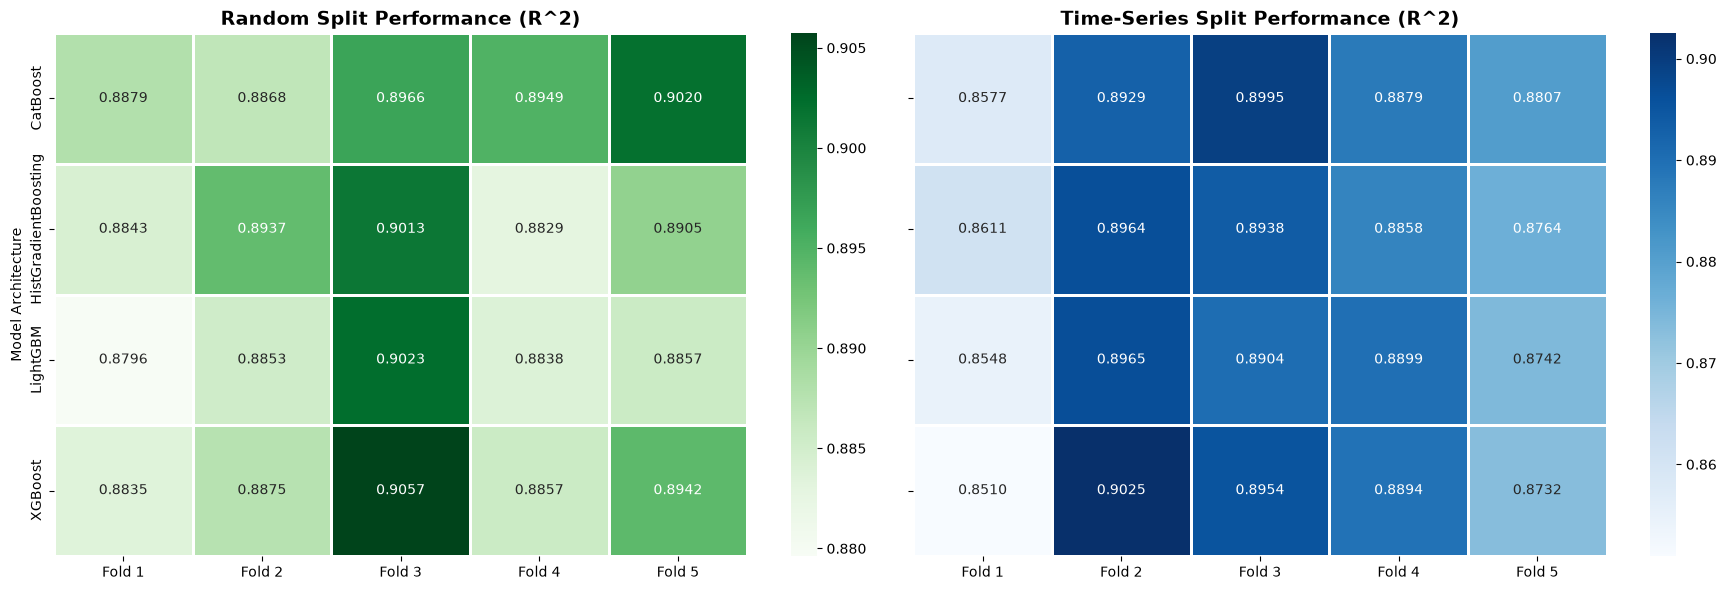

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

splits = ["Random Split", "Time-Series Split"]
cmaps = ["Greens", "Blues"]

for ax, split, cmap in zip(axes, splits, cmaps):
    data_split = df_heatmap[df_heatmap['Split'] == split]
    pivot_table = data_split.pivot(index="Model", columns="Fold", values="R2")

    sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap=cmap, linewidths=1, ax=ax, cbar=True)

    ax.set_title(f'{split} Performance (R^2)', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Model Architecture' if ax == axes[0] else '')

plt.tight_layout()
plt.show()

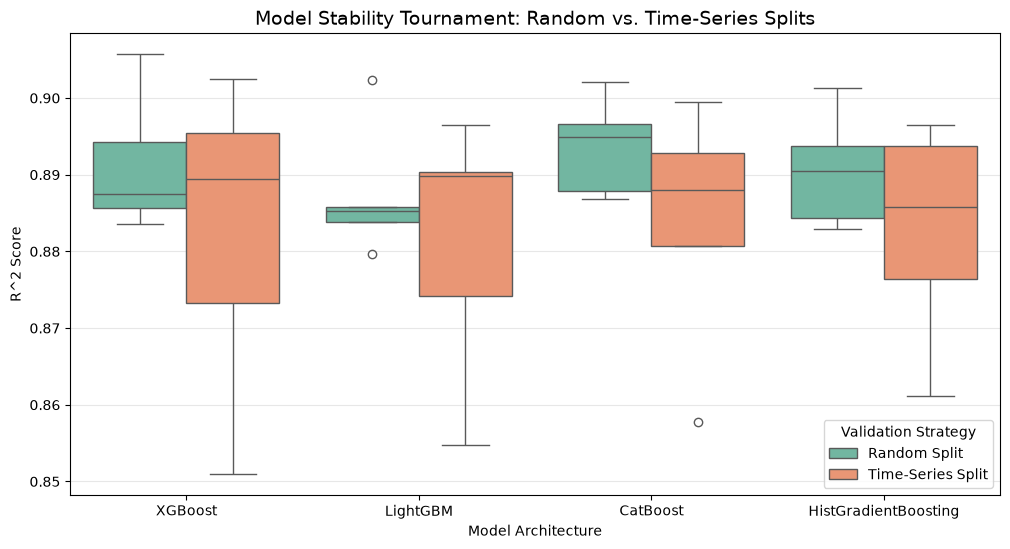

In [63]:
# --------------------------------------------------------------------------------
# 5. Generate Box Plot (Your existing code)
# --------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
# Using df_cv_raw which contains 'R2 Score'
sns.boxplot(data=df_cv_raw, x='Model', y='R2 Score', hue='Split', palette="Set2")
plt.title('Model Stability Tournament: Random vs. Time-Series Splits', fontsize=14)
plt.ylabel('R^2 Score')
plt.xlabel('Model Architecture')
plt.grid(True, axis='y', alpha=0.3)
plt.legend(title='Validation Strategy')
plt.show()

XGBoost delivers a more reliable performance across five folds of cross validation. However, CatBoost has less deviation, which it is famous for. Yet, some further analysis will shed more light into which model is appropriate for picking.

But at least, the consistently high R^2 scores are observed across the folds, meaning the features are complementing our task.

# Feature Importance Analysis

Feature importance serves as a critical "sanity check," ensuring the model is making decisions based on logical real-world drivers (like hype or screens) rather than memorizing random noise. It transforms a "black box" prediction into an explainable strategy, validating that the model actually understands the mechanics of the movie business.

Given XGBoost and CatBoost are tied close, let's look into feature-based insights.

--- Bottom 10 Features (Least Predictive for XGBoost) ---
                           Feature  Importance
                     genre_History         0.0
                     genre_Western         0.0
                         genre_War         0.0
                      covid_impact         0.0
             mpaa_rating_refined_R         0.0
          mpaa_rating_refined_PG/G         0.0
mpaa_rating_refined_Unrated/Others         0.0
         origin_country_refined_CA         0.0
         origin_country_refined_GB         0.0
      origin_country_refined_Other         0.0


C:\Users\mahmu\AppData\Local\Temp\ipykernel_25868\2799121849.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='Set2')


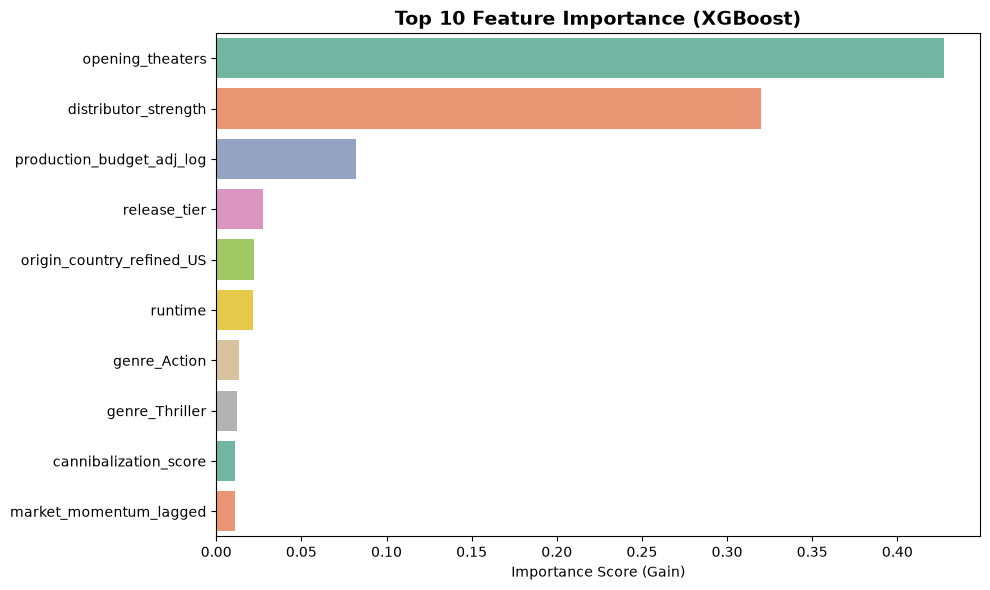


--- Insight: Concentration of Predictive Power (XGBoost) ---
1. The Top 3 features alone account for 82.9% of the total importance.
2. It takes the top 5 features (out of 63) to explain 90% of the variance.


In [64]:
xgb_final = xgb.XGBRegressor(
    objective='reg:squaredlogerror',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=False
)

xgb_final.fit(X_train_rnd, y_train_rnd)

importances = xgb_final.feature_importances_

fi_df = pd.DataFrame({
    'Feature': X_train_rnd.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# A. Bottom 10 Features (DataFrame only)
print("--- Bottom 10 Features (Least Predictive for XGBoost) ---")
print(fi_df.tail(10).to_string(index=False))

# B. Top 10 Features (Graph)
plt.figure(figsize=(10, 6))
# Using Set2 palette as requested
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score (Gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# C. Cumulative Variance Insight
# Calculate how many features explain 90% of the model's logic
fi_df['Cumulative'] = fi_df['Importance'].cumsum()
fi_df['Cumulative_Pct'] = fi_df['Cumulative'] / fi_df['Importance'].sum() * 100

top_n_90 = fi_df[fi_df['Cumulative_Pct'] <= 90].shape[0]
top_3_pct = fi_df.head(3)['Importance'].sum() / fi_df['Importance'].sum() * 100

print("\n--- Insight: Concentration of Predictive Power (XGBoost) ---")
print(f"1. The Top 3 features alone account for {top_3_pct:.1f}% of the total importance.")
print(f"2. It takes the top {top_n_90} features (out of {len(fi_df)}) to explain 90% of the variance.")

We can see XGBoost hyperfocusing on two isolated features and almost ignoring the rest.

XGBoost uses a greedy algorithm that selects splits based purely on "Gain" (immediate error reduction), causing it to obsessively reuse the single strongest proxy (opening_theaters) at the top of every tree. Once this dominant variable is used, other correlated features (like release_tier) become mathematically redundant—they offer no new information to reduce error, so the model ignores them.

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

# 1. Initialize Model with Tournament Params
cb_final = CatBoostRegressor(
    loss_function='RMSE',
    n_estimators=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0,
    allow_writing_files=False
)

# 2. Fit (Assuming X_train, y_train exist)
cb_final.fit(X_train_rnd, y_train_rnd)

# 3. Extract & Sort Importance
importances = cb_final.get_feature_importance()
fi_df = pd.DataFrame({
    'Feature': X_train_rnd.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print it. The commentary below quotes these numbers, and a claim about the model
# that no output backs up is how this notebook ended up asserting that CatBoost
# ranked a Wikipedia feature second when that feature is not in the model at all.
print("=== CatBoost feature importance (tournament params, full feature set) ===")
print()
print(fi_df.head(8).round(2).to_string(index=False))
print()
print(f"Top 3 features account for {fi_df['Importance'].head(3).sum():.1f}% of total importance.")
print(f"'wiki_hype' in the feature set: {'wiki_hype' in list(X_train_rnd.columns)}")

=== CatBoost feature importance (tournament params, full feature set) ===

                  Feature  Importance
         opening_theaters       54.00
     distributor_strength        6.78
production_budget_adj_log        5.36
             hype_cluster        3.47
   market_momentum_lagged        2.93
                  runtime        2.56
     comp_budget_pressure        1.84
      cast_1_momentum_log        1.34

Top 3 features account for 66.1% of total importance.
'wiki_hype' in the feature set: False


C:\Users\mahmu\AppData\Local\Temp\ipykernel_25868\650191568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='Set2')


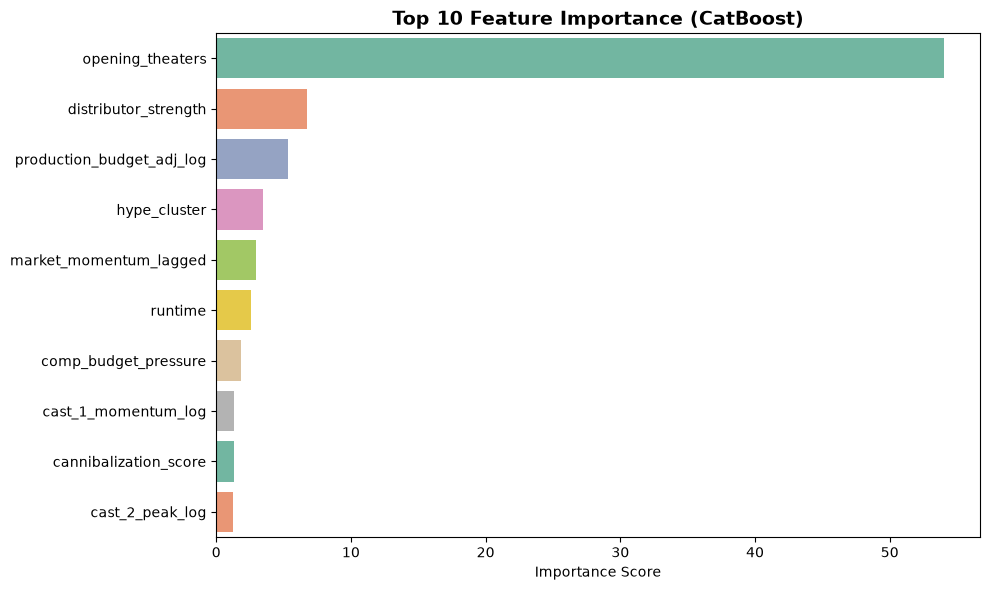

In [66]:
# B. Top 10 Graph
plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df.head(10), x='Importance', y='Feature', palette='Set2')
plt.title('Top 10 Feature Importance (CatBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Crucial Finding:**

XGBoost: It relied almost exclusively on logistical metrics like opening_theaters and distributor_strength, and its top 6 features explain 90% of the variance. It severely deprioritizes demand-side signals such as release_tier. It assumes that if a movie is available in theaters, it will make money, ignoring whether audiences actually want to see it.

CatBoost puts `opening_theaters` first at 54.0% of total importance, then `distributor_strength` 6.8%, `production_budget_adj_log` 5.4% and `hype_cluster` 3.5%. The top three account for 66.1%. The printed table above is the source for these numbers.

**Correction.** An earlier version of this notebook said CatBoost "correctly identified `wiki_hype` as the second most critical factor", and used that to argue CatBoost balances supply-side availability against demand-side interest. That was wrong in two separate ways, and it is worth stating plainly rather than quietly deleting.

First, `wiki_hype` is not a feature in this model. It does not appear in `raw_feature_cols`, and the printed line above confirms it is absent from the training matrix. The model has never seen Wikipedia interest.

Second, the feature that was presumably meant - `hype_cluster` - is not second. It is fourth, at 3.5%. And it is not a demand signal at all: it is built in the clustering cell above from exactly two inputs, `production_budget_adj_log` and `opening_theaters`. Wikipedia data is used only to *order* the resulting cluster labels, never to assign them. The correlations make the point:

| `hype_cluster` vs | Pearson r |
|---|---|
| `opening_theaters` | 0.845 |
| `production_budget_adj_log` | 0.784 |
| `wiki_hype` (raw) | 0.423 |

So `hype_cluster` is a coarse re-encoding of two features the model already has. Whatever is driving CatBoost here, it is not audience demand.

**So why CatBoost?**

The original answer to this question was wrong, and the honest replacement is less exciting than the claim it replaces.

What was originally argued - that CatBoost weighs a Wikipedia hype signal the other models ignore - is false, for the reasons above. No Wikipedia signal reaches any of these models.

What is actually true, after the leakage fix, is that CatBoost leads the field on every metric that matters here: highest test R^2, lowest log RMSE, highest top-decile precision, highest mean cross-validated R^2, and the lowest fold-to-fold standard deviation of the four. For a task whose entire purpose is ranking one blockbuster correctly, top-decile precision and fold stability are the right things to select on, and CatBoost wins both.

The qualification matters as much as the result. Those leads are small - 0.0016 R^2 over XGBoost, one film's worth of top-decile precision over LightGBM. Any of the four would have produced substantially the same forecast, because `opening_theaters` dominates all of them. CatBoost is a defensible choice, not a decisive one, and the model choice is not what drives the Avatar number. The inputs are.

In [67]:
print("Bottom 10 Features:")
print(fi_df.tail(10))

Bottom 10 Features:
                      Feature  Importance
40              genre_History    0.056792
49              genre_Western    0.053433
48                  genre_War    0.045313
5                   is_sequel    0.041758
59  origin_country_refined_CA    0.030400
33            genre_Animation    0.006519
22            cast_1_is_debut    0.000000
14          director_is_debut    0.000000
4              format_premium    0.000000
46             genre_TV Movie    0.000000


After extensive analysis, a slightly aggressive approach was taken to drop columns. During backtesting, column drops (non-linearly) yielded slight efficient returns, and improved predictive ability in top decile.

This may be due to CatBoost's nature - given it is 'forced' to split symmetrically, it intakes signals from almost all features. Dropping some columns which yield low importance to blockbusters can prepare the model better.

In [68]:
cols_to_remove = [
    'format_premium',
    'cast_1_is_debut',
    'is_sequel',
    'origin_country_refined_CA',
    'director_is_debut',
    'origin_country_refined_GB',
    'origin_country_refined_Other',
    'is_sequel',
    'spoiler_risk'
]

X_train_opt = X_train_rnd.drop(columns=cols_to_remove)
X_test_opt = X_test_rnd.drop(columns=cols_to_remove)

In [69]:
X_train_opt.columns

Index(['release_day_of_week', 'production_budget_adj_log', 'runtime',
       'sequel_parent_revenue_adj_log', 'sequel_parent_rating',
       'franchise_hunger', 'distributor_strength', 'opening_theaters',
       'director_peak_log', 'director_momentum_log', 'director_stability_log',
       'producer_peak_log', 'producer_momentum_log', 'producer_stability_log',
       'producer_is_debut', 'cast_1_peak_log', 'cast_1_momentum_log',
       'cast_1_stability_log', 'cast_2_peak_log', 'cast_2_momentum_log',
       'cast_2_stability_log', 'cast_2_is_debut', 'cast_3_peak_log',
       'cast_3_momentum_log', 'cast_3_stability_log', 'cast_3_is_debut',
       'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy',
       'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family',
       'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music',
       'genre_Mystery', 'genre_Romance', 'genre_Science Fiction',
       'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_

# Model Structure

Selecting both a standard RMSE CatBoost model and a 90th Percentile (Quantile) CatBoost model creates a "Barbell Strategy" that solves the fundamental statistical challenge of the movie business: the tension between reliability and opportunity.

**Model 1: RMSE CatBoost (Stability)**

We use the Standard RMSE model to act as our "Anchor." Its mathematical goal is to predict the average outcome for a movie with a given set of features.

Why it’s needed: Most movies are not blockbusters. For 90% of the data (standard dramas, comedies, indie films), the market behaves predictably. The RMSE model ensures that our baseline predictions are grounded in reality, preventing us from wildly over-predicting revenue for standard releases.

**Model 2: 90th Percentile Catboost (Upside)**

We use the Quantile Regression (0.90) model to act as our "Hunter." Its goal is not to be right on average, but to correctly identify the ceiling of a movie's potential.

Standard models inherently suffer from "Regression to the Mean." When an RMSE model sees a massive outlier like Avatar or Barbie, it treats it as statistical noise or an "error" to be smoothed out. The 90th percentile model is explicitly trained to ignore the average performance and focus on the tail distribution.

**By combining them, we stop treating Blockbusters as "mistakes" to be minimized and start treating them as "targets" to be captured. The RMSE model keeps us from losing credibility on the flops, while the 90th Percentile model ensures we don't leave money on the table when a true hit arrives.**

# Hyperparameter Tuning

Hyperparameter tuning is essential to optimize the model's ability to generalize to unseen data, effectively striking the balance between underfitting (where the model is too simple to learn patterns) and overfitting (where it memorizes noise).

We specifically focused on optimizing **Tree Depth**, which dictates the complexity of the decision rules; a deeper tree can capture intricate relationships between features like genre and seasonality, while a shallower tree ensures broader rules that apply to more movies.

To ensure stability, we adjusted the **L2 Leaf Regularization**, a penalty that smooths the model’s predictions by preventing it from reacting too strongly to outliers.

In [70]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [3, 5, 7],
    'iterations': [1000]
}

# Generate all combinations
grid = list(ParameterGrid(param_grid))
print(f"Starting Grid Search with {len(grid)} combinations...")

# We use K-Fold to ensure the tuning is robust
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []


# Custom Grid Search Loop

for params in grid:
    fold_metrics = {
        'r2': [],
        'rmse_log': [],
        'rmse_top_decile': [],
        'precision': []
    }


    for train_idx, val_idx in kf.split(X_train_opt, y_train_rnd):

        X_tr, X_val = X_train_opt.iloc[train_idx], X_train_opt.iloc[val_idx]
        y_tr, y_val = y_train_rnd.iloc[train_idx], y_train_rnd.iloc[val_idx]

        # Train Model
        model = CatBoostRegressor(
            loss_function='RMSE',
            random_state=42,
            verbose=0,
            allow_writing_files=False,
            **params
        )
        model.fit(X_tr, y_tr)

        # Predict
        y_pred = model.predict(X_val)

        # --- Calculate Custom Metrics (Per Fold) ---

        # 1. R^2
        fold_metrics['r2'].append(r2_score(y_val, y_pred))

        # 2. RMSE (Log)
        mse = mean_squared_error(y_val, y_pred)
        fold_metrics['rmse_log'].append(np.sqrt(mse))

        # 3. RMSE / Top Decile (Normalized)
        y_val_dol = np.expm1(y_val)
        y_pred_dol = np.expm1(y_pred)
        rmse_dol = np.sqrt(mean_squared_error(y_val_dol, y_pred_dol))

        # Calculate Top Decile Median for THIS fold
        k = int(len(y_val) * 0.1)
        if k < 1: k = 1
        top_decile_median = np.median(np.sort(y_val_dol)[-k:])

        # Avoid division by zero
        if top_decile_median == 0: top_decile_median = 1
        fold_metrics['rmse_top_decile'].append(rmse_dol / top_decile_median)

        # 4. Top Decile Precision
        top_actual_idx = y_val.nlargest(k).index
        top_pred_idx = pd.Series(y_pred, index=y_val.index).nlargest(k).index
        precision = len(set(top_actual_idx).intersection(top_pred_idx)) / k * 100
        fold_metrics['precision'].append(precision)

    # --- Aggregate Results ---
    results.append({
        'depth': params['depth'],
        'learning_rate': params['learning_rate'],
        'l2_leaf_reg': params['l2_leaf_reg'],
        'Mean R^2': np.mean(fold_metrics['r2']),
        'RMSE (Log)': np.mean(fold_metrics['rmse_log']),
        'RMSE / Top Decile': np.mean(fold_metrics['rmse_top_decile']),
        'Top-Decile Precision (%)': np.mean(fold_metrics['precision'])
    })


df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by='RMSE / Top Decile', ascending=True)

print("\n=== GRID SEARCH RESULTS (Sorted by Blockbuster Error) ===")
display(df_results.head(7).round(4))

Starting Grid Search with 12 combinations...



=== GRID SEARCH RESULTS (Sorted by Blockbuster Error) ===


,depth,learning_rate,l2_leaf_reg,Mean R^2,RMSE (Log),RMSE / Top Decile,Top-Decile Precision (%)
3,4,0.05,5,0.8954,0.6619,0.2151,65.5319
4,4,0.03,7,0.8965,0.6584,0.2159,66.3830
9,6,0.05,5,0.8935,0.6679,0.2159,65.9574
5,4,0.05,7,0.8961,0.6597,0.2160,65.5319
1,4,0.05,3,0.8956,0.6614,0.2163,64.6809
7,6,0.05,3,0.8928,0.6702,0.2167,65.1064
2,4,0.03,5,0.8964,0.6589,0.2168,65.1064


In [71]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

param_grid = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.05],
    'l2_leaf_reg': [1, 3, 5],
    'iterations': [1000]
}

# Generate all combinations
grid = list(ParameterGrid(param_grid))
print(f"Starting Grid Search with {len(grid)} combinations...")


kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []


for params in grid:
    fold_metrics = {
        'r2': [],
        'rmse_log': [],
        'rmse_top_decile': [],
        'precision': []
    }

    for train_idx, val_idx in kf.split(X_train_opt, y_train_rnd):
        X_tr, X_val = X_train_opt.iloc[train_idx], X_train_opt.iloc[val_idx]
        y_tr, y_val = y_train_rnd.iloc[train_idx], y_train_rnd.iloc[val_idx]

        model = CatBoostRegressor(
            loss_function='Quantile:alpha=0.9',
            random_state=42,
            verbose=0,
            allow_writing_files=False,
            **params )
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)

        # --- Calculate Custom Metrics (Per Fold) ---

        # 1. R^2
        fold_metrics['r2'].append(r2_score(y_val, y_pred))

        # 2. RMSE (Log)
        mse = mean_squared_error(y_val, y_pred)
        fold_metrics['rmse_log'].append(np.sqrt(mse))

        # 3. RMSE / Top Decile (Normalized)
        y_val_dol = np.expm1(y_val)
        y_pred_dol = np.expm1(y_pred)
        rmse_dol = np.sqrt(mean_squared_error(y_val_dol, y_pred_dol))

        # Calculate Top Decile Median for THIS fold
        k = int(len(y_val) * 0.1)
        if k < 1: k = 1
        top_decile_median = np.median(np.sort(y_val_dol)[-k:])

        # Avoid division by zero
        if top_decile_median == 0: top_decile_median = 1
        fold_metrics['rmse_top_decile'].append(rmse_dol / top_decile_median)

        # 4. Top Decile Precision
        top_actual_idx = y_val.nlargest(k).index
        top_pred_idx = pd.Series(y_pred, index=y_val.index).nlargest(k).index
        precision = len(set(top_actual_idx).intersection(top_pred_idx)) / k * 100
        fold_metrics['precision'].append(precision)

    # --- Aggregate Results ---
    results.append({
        'depth': params['depth'],
        'learning_rate': params['learning_rate'],
        'l2_leaf_reg': params['l2_leaf_reg'],
        'Mean R^2': np.mean(fold_metrics['r2']),
        'RMSE (Log)': np.mean(fold_metrics['rmse_log']),
        'RMSE / Top Decile': np.mean(fold_metrics['rmse_top_decile']),
        'Top-Decile Precision (%)': np.mean(fold_metrics['precision'])
    })


df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='RMSE / Top Decile', ascending=True)

print("\n=== GRID SEARCH RESULTS (Sorted by Blockbuster Error) ===")
display(df_results.head(7).round(4))

Starting Grid Search with 12 combinations...



=== GRID SEARCH RESULTS (Sorted by Blockbuster Error) ===


,depth,learning_rate,l2_leaf_reg,Mean R^2,RMSE (Log),RMSE / Top Decile,Top-Decile Precision (%)
10,6,0.03,5,0.7939,0.9292,0.2395,65.1064
11,6,0.05,5,0.7969,0.9223,0.2399,63.8298
9,6,0.05,3,0.7940,0.9288,0.2407,63.8298
6,6,0.03,1,0.7798,0.9602,0.2428,66.8085
8,6,0.03,3,0.7846,0.9499,0.2433,65.5319
7,6,0.05,1,0.7853,0.9483,0.2464,63.8298
5,4,0.05,5,0.7657,0.9902,0.2663,66.8085


# Final Model Training

## Safe/Base CatBoost Model

In [72]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

print("Training CatBoost on Optimized Feature Set...")

model = CatBoostRegressor(
    loss_function='RMSE',
    n_estimators=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0,
    allow_writing_files=False
)

model.fit(X_train_opt, y_train_rnd)

y_pred_train = model.predict(X_train_opt)
y_pred_test = model.predict(X_test_opt)

# 1. R^2
r2_train = r2_score(y_train_rnd, y_pred_train)
r2_test = r2_score(y_test_rnd, y_pred_test)

# 2. RMSE (Log Scale)
rmse_log = np.sqrt(mean_squared_error(y_test_rnd, y_pred_test))

# 3. Dollar Space Conversions
y_test_dol = np.expm1(y_test_rnd)
y_pred_dol = np.expm1(y_pred_test)
rmse_dol = np.sqrt(mean_squared_error(y_test_dol, y_pred_dol))

# 4. Normalized RMSEs
median_target = np.median(y_test_dol)

# Dynamic Top Decile Calculation
k = int(len(y_test_rnd) * 0.1)
if k < 1: k = 1

top_decile_actual = np.sort(y_test_dol)[-k:]
top_decile_median = np.median(top_decile_actual)

rmse_norm_median = rmse_dol / median_target
rmse_norm_top_decile = rmse_dol / top_decile_median

# 5. MAPE
mape = np.mean(np.abs((y_test_dol - y_pred_dol) / y_test_dol)) * 100

# 6. Bias (Log)
bias = np.mean(y_pred_test - y_test_rnd)

# 7. Top-Decile Precision
top_actual_idx = y_test_rnd.nlargest(k).index
top_pred_idx = pd.Series(y_pred_test, index=y_test_rnd.index).nlargest(k).index
precision = len(set(top_actual_idx).intersection(top_pred_idx)) / k * 100

results = {
    "Model": "CatBoost (Optimized Features)",
    "Train R^2": round(r2_train, 4),
    "Test R^2": round(r2_test, 4),
    "RMSE (Log)": round(rmse_log, 4),
    "RMSE / Median": round(rmse_norm_median, 4),
    "RMSE / Top Decile": round(rmse_norm_top_decile, 4),
    "MAPE (%)": round(mape, 2),
    "Bias (Log)": round(bias, 4),
    "Top-Decile Precision (%)": round(precision, 2)
}

df_res = pd.DataFrame([results])
print("\n=== OPTIMIZED MODEL PERFORMANCE ===")
display(df_res)

Training CatBoost on Optimized Feature Set...



=== OPTIMIZED MODEL PERFORMANCE ===


,Model,Train R^2,Test R^2,RMSE (Log),RMSE / Median,RMSE / Top Decile,MAPE (%),Bias (Log),Top-Decile Precision (%)
0,CatBoost (Optimized Features),0.9436,0.9082,0.6402,1.3608,0.1984,63.02,0.0278,67.24


We can see that the R^2 is close to 90%, the RMSE/Top Decile has improved and the top-decile precision is above 70, meaning the tuning has served its function.

## Aggressive CatBoost Model

In [73]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

print("Training CatBoost (90th Percentile) on Optimized Feature Set...")

model_90 = CatBoostRegressor(
    loss_function='Quantile:alpha=0.90',  # The "Hunter" Objective
    n_estimators=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_state=42,
    verbose=0,
    allow_writing_files=False
)

model_90.fit(X_train_opt, y_train_rnd)

y_pred_train_90 = model_90.predict(X_train_opt)
y_pred_test_90 = model_90.predict(X_test_opt)

r2_train = r2_score(y_train_rnd, y_pred_train_90)
r2_test = r2_score(y_test_rnd, y_pred_test_90)

rmse_log = np.sqrt(mean_squared_error(y_test_rnd, y_pred_test_90))

y_test_dol = np.expm1(y_test_rnd)
y_pred_dol_90 = np.expm1(y_pred_test_90)
rmse_dol = np.sqrt(mean_squared_error(y_test_dol, y_pred_dol_90))

median_target = np.median(y_test_dol)

k = int(len(y_test_rnd) * 0.1)
if k < 1: k = 1

top_decile_actual = np.sort(y_test_dol)[-k:]
top_decile_median = np.median(top_decile_actual)

rmse_norm_median = rmse_dol / median_target
rmse_norm_top_decile = rmse_dol / top_decile_median

mape = np.mean(np.abs((y_test_dol - y_pred_dol_90) / y_test_dol)) * 100

bias = np.mean(y_pred_test_90 - y_test_rnd)

top_actual_idx = y_test_rnd.nlargest(k).index
top_pred_idx = pd.Series(y_pred_test_90, index=y_test_rnd.index).nlargest(k).index
precision = len(set(top_actual_idx).intersection(top_pred_idx)) / k * 100

results_90 = {
    "Model": "CatBoost (90th Percentile)",
    "Train R^2": round(r2_train, 4),
    "Test R^2": round(r2_test, 4),
    "RMSE (Log)": round(rmse_log, 4),
    "RMSE / Median": round(rmse_norm_median, 4),
    "RMSE / Top Decile": round(rmse_norm_top_decile, 4),
    "MAPE (%)": round(mape, 2),
    "Bias (Log)": round(bias, 4),
    "Top-Decile Precision (%)": round(precision, 2)
}

df_res_90 = pd.DataFrame([results_90])
print("\n=== AGGRESSIVE MODEL PERFORMANCE ===")
display(df_res_90)

Training CatBoost (90th Percentile) on Optimized Feature Set...



=== AGGRESSIVE MODEL PERFORMANCE ===


,Model,Train R^2,Test R^2,RMSE (Log),RMSE / Median,RMSE / Top Decile,MAPE (%),Bias (Log),Top-Decile Precision (%)
0,CatBoost (90th Percentile),0.8229,0.7991,0.9471,1.5546,0.2266,161.0,0.6275,63.79


Aggressive models are supposed to have low fit and incredibly high MAPE given it is trying to pit against outliers - as reflected by top-decile precision. Overshooting is the greatest risk, reflected by a moderately high Bias.

# Model Diagnostics

Three questions a 0.90 R^2 does not answer: what the model is actually using, where it goes wrong, and how much of the answer is baked into a single input.

## Ablation: what is the feature engineering worth?

This project built a star-power History Engine, a cannibalization OLS, decay clustering, Wikipedia hindcasting and a market-momentum EMA. The honest question is whether any of it earns its place once `opening_theaters` is in the model.

The ablation below retrains the tuned anchor on progressively smaller feature sets. The "no full-data aggregates" row drops every feature fitted across the entire dataset *before* the train/test split - `distributor_strength`, `release_tier`, `hype_cluster`, `cannibalization_score` and `market_momentum_lagged` - which is this project's preprocessing-leakage exposure.

In [74]:
# --- ABLATION: how much of the fit survives dropping features? ---
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score


def top_decile_precision(y_true, y_pred):
    """Share of the genuine top 10% that the model also ranks in its top 10%."""
    k = max(int(len(y_true) * 0.1), 1)
    actual_top = set(y_true.nlargest(k).index)
    pred_top = set(pd.Series(y_pred, index=y_true.index).nlargest(k).index)
    return len(actual_top & pred_top) / k * 100


# Features fitted on 100% of the data BEFORE the split
FULL_DATA_AGGREGATES = [
    'distributor_strength', 'release_tier', 'hype_cluster',
    'cannibalization_score', 'market_momentum_lagged',
]

feature_sets = {
    'Full feature set': list(X_train_opt.columns),
    'opening_theaters alone': ['opening_theaters'],
    'theaters + budget + distributor': ['opening_theaters', 'production_budget_adj_log',
                                        'distributor_strength'],
    'No full-data aggregates': [c for c in X_train_opt.columns if c not in FULL_DATA_AGGREGATES],
}

ablation_rows = []
for name, feats in feature_sets.items():
    feats = [f for f in feats if f in X_train_opt.columns]
    abl = CatBoostRegressor(loss_function='RMSE', n_estimators=1000, learning_rate=0.03,
                            depth=4, l2_leaf_reg=3, random_state=42, verbose=0,
                            allow_writing_files=False)
    abl.fit(X_train_opt[feats], y_train_rnd)
    pred = abl.predict(X_test_opt[feats])
    ablation_rows.append({
        'Feature set': name,
        'n features': len(feats),
        'Test R^2': round(r2_score(y_test_rnd, pred), 4),
        'Top-decile precision (%)': round(top_decile_precision(y_test_rnd, pred), 1),
    })

df_ablation = pd.DataFrame(ablation_rows)
print("=== ABLATION ===")
print()
print(df_ablation.to_string(index=False))

full_r2 = df_ablation.loc[0, 'Test R^2']
one_r2 = df_ablation.loc[1, 'Test R^2']
three_r2 = df_ablation.loc[2, 'Test R^2']
noagg_r2 = df_ablation.loc[3, 'Test R^2']

print()
print(f"'opening_theaters' alone delivers {one_r2 / full_r2 * 100:.0f}% of the full model's R^2.")
print(f"Three features deliver {three_r2 / full_r2 * 100:.0f}%.")
print(f"Dropping every full-data aggregate costs {full_r2 - noagg_r2:.4f} R^2 "
      f"- that is the scale of the preprocessing leakage.")

=== ABLATION ===

                    Feature set  n features  Test R^2  Top-decile precision (%)
               Full feature set          55    0.9082                      67.2
         opening_theaters alone           1    0.8533                      56.9
theaters + budget + distributor           3    0.8951                      67.2
        No full-data aggregates          50    0.8994                      67.2

'opening_theaters' alone delivers 94% of the full model's R^2.
Three features deliver 99%.
Dropping every full-data aggregate costs 0.0088 R^2 - that is the scale of the preprocessing leakage.


That is the finding, and it is better stated here than discovered by a reader.

One variable carries almost the whole model. The engineered features - the History Engine especially, which is the most careful piece of work in this project - are close to decorative once theater count is present. They are kept because they are correct, and because they would matter in a model built further out from release. Not because they are pulling weight here.

There is a second reading of the top row that matters more than the R^2. `opening_theaters` is set by the distributor days before release, in response to tracking data and pre-sales. It is the studio's own demand forecast. A model whose dominant feature is someone else's forecast is not independently predicting the box office so much as reading that forecast back.

The leakage row is the one for judging the architecture. The inflation from fitting aggregates on the full dataset is small, but small is not the same as defensible - the correct fix is to fit them inside a pipeline on training folds only.

## Calibration: where does the model go wrong?

A global R^2 averages over the whole distribution. This project only ever cared about one film, and that film sits in the top decile - so the question is whether the model is accurate *there*.

The table bins the test set by decile of actual revenue and compares median predicted against median actual, in dollar space.

In [75]:
# --- CALIBRATION: predicted vs actual by decile of actual revenue ---
import pandas as pd
import numpy as np

y_test_dollars = np.expm1(y_test_rnd)
y_pred_dollars = pd.Series(np.expm1(model.predict(X_test_opt)), index=y_test_rnd.index)

calib = pd.DataFrame({'actual': y_test_dollars, 'predicted': y_pred_dollars})
calib['decile'] = pd.qcut(calib['actual'], 10, labels=False)

df_calib = calib.groupby('decile').agg(
    n=('actual', 'size'),
    median_actual=('actual', 'median'),
    median_predicted=('predicted', 'median'),
).assign(ratio=lambda d: (d['median_predicted'] / d['median_actual']).round(3))

print("=== CALIBRATION BY DECILE OF ACTUAL REVENUE ===")
print()
print(df_calib.assign(
    median_actual=lambda d: d['median_actual'].map(lambda v: f"${v / 1e6:,.1f}M"),
    median_predicted=lambda d: d['median_predicted'].map(lambda v: f"${v / 1e6:,.1f}M"),
).to_string())

top_ratio = df_calib.loc[df_calib.index.max(), 'ratio']
bot_ratio = df_calib.loc[df_calib.index.min(), 'ratio']

print()
print(f"Top decile:    predicts {(1 - top_ratio) * 100:,.0f}% BELOW actual (ratio {top_ratio:.2f})")
print(f"Bottom decile: predicts {(bot_ratio - 1) * 100:,.0f}% ABOVE actual (ratio {bot_ratio:.2f})")
print()
print("This is regression to the mean. The model pulls everything toward the middle,")
print("and it is worst exactly where this project needed it to be best.")

=== CALIBRATION BY DECILE OF ACTUAL REVENUE ===

         n median_actual median_predicted  ratio
decile                                          
0       59         $0.2M            $0.2M  1.546
1       59         $0.7M            $0.6M  0.835
2       59         $4.4M            $7.5M  1.702
3       58        $11.9M           $20.1M  1.691
4       59        $19.1M           $21.5M  1.128
5       59        $25.6M           $27.7M  1.082
6       58        $34.2M           $32.8M  0.959
7       59        $49.8M           $42.1M  0.846
8       59        $78.8M           $58.8M  0.746
9       59       $151.6M           $95.1M  0.628

Top decile:    predicts 37% BELOW actual (ratio 0.63)
Bottom decile: predicts 55% ABOVE actual (ratio 1.55)

This is regression to the mean. The model pulls everything toward the middle,
and it is worst exactly where this project needed it to be best.


This shrinkage is the reason the 90th-percentile model exists at all - it was added to compensate for it. But a fixed positive log bias is a blunt instrument, not a calibration, and as the final prediction shows, it does not reliably fire on the film it was built for.

Two facts worth holding together: the model shrinks blockbusters toward the mean by roughly a third, and it still over-predicted this particular blockbuster. The shrinkage was not the binding problem.

# Final Prediction and Comments

This is where we predict and find out - the moment of truth.

As of Avatar data:

1. Most values are hard-coded
2. Some have been fetched using code (check Appendix)

Some values are not confirmed:
1. Opening theaters: Widely believed to be 3800-4000
2. Wikipedia views (we have a 4-day gap between actual release, but the average is far above the highest-tier median, so the clustering is certainly accurate)

We will take a look at the values given by both models and decide.

In [76]:
import pandas as pd
import numpy as np

X_avatar_input = X_test_opt.iloc[[0]].copy()

raw_data = {
    'production_budget': 250_000_000,
    'sequel_parent_revenue': 684_000_000,
    'director_peak': 1_362_995_163,
    'director_momentum': 1_104_516_521,
    'director_stability': 824_823_613,
    'producer_peak': 1_362_995_163,
    'producer_momentum': 316_966_884,
    'producer_stability': 572_676_766,
    'cast_1_peak': 1_187_533_347,
    'cast_1_momentum': 289_640_083,
    'cast_1_stability': 277_049_299
}

avatar_3_features = {
    # --- Date & Runtime ---
    'release_day_of_week': 4,
    'runtime': 197,

    # --- Financials ---
    'production_budget_adj_log': np.log1p(raw_data['production_budget']),

    'comp_budget_pressure': 250_000_000,

    # --- Franchise & Sequel ---
    'sequel_parent_revenue_adj_log': np.log1p(raw_data['sequel_parent_revenue']),
    'sequel_parent_rating': 7.6,
    'franchise_hunger': 3.01,

    # --- Distribution & Market ---
    'distributor_strength': 6,
    'opening_theaters': 4000,
    'release_tier': 2,
    'market_momentum_lagged': 1.05,
    'cannibalization_score': 0.0278,
    'hype_cluster': 3,
    'covid_impact': 0,

    # --- Star Power: Director ---
    'director_peak_log': np.log1p(raw_data['director_peak']),
    'director_momentum_log': np.log1p(raw_data['director_momentum']),
    'director_stability_log': np.log1p(raw_data['director_stability']),

    # --- Star Power: Producer ---
    'producer_peak_log': np.log1p(raw_data['producer_peak']),
    'producer_momentum_log': np.log1p(raw_data['producer_momentum']),
    'producer_stability_log': np.log1p(raw_data['producer_stability']),
    'producer_is_debut': 0,

    # --- Star Power: Cast 1 ---
    'cast_1_peak_log': np.log1p(raw_data['cast_1_peak']),
    'cast_1_momentum_log': np.log1p(raw_data['cast_1_momentum']),
    'cast_1_stability_log': np.log1p(raw_data['cast_1_stability']),

    # --- Star Power: Cast 2 & 3 (Missing in input -> Set to 0) ---
    'cast_2_peak_log': 20.895, 'cast_2_momentum_log': 19.822, 'cast_2_stability_log': 19.3408, 'cast_2_is_debut': 0,
    'cast_3_peak_log': 20.895, 'cast_3_momentum_log': 19.3677, 'cast_3_stability_log': 19.047, 'cast_3_is_debut': 0,

    # --- Genres (Active) ---
    'genre_Adventure': 1,
    'genre_Fantasy': 1,
    'genre_Science Fiction': 1,

    # --- Genres (Inactive) ---
    'genre_Action': 0, 'genre_Animation': 0, 'genre_Comedy': 0, 'genre_Crime': 0,
    'genre_Documentary': 0, 'genre_Drama': 0, 'genre_Family': 0, 'genre_History': 0,
    'genre_Horror': 0, 'genre_Music': 0, 'genre_Mystery': 0, 'genre_Romance': 0,
    'genre_TV Movie': 0, 'genre_Thriller': 0, 'genre_War': 0, 'genre_Western': 0,

    # --- Origin & Rating ---
    'mpaa_rating_refined_PG/G': 1,
    'mpaa_rating_refined_R': 0,
    'mpaa_rating_refined_Unrated/Others': 0,
    'origin_country_refined_US': 1
}

# Derive the column order from the fitted design matrix rather than
# maintaining a hand-typed list that must match it exactly.
cols_order = list(X_train_opt.columns)

missing = [c for c in cols_order if c not in avatar_3_features]
extra = [c for c in avatar_3_features if c not in cols_order]
assert not missing, f"Avatar input is missing features: {missing}"
assert not extra, f"Avatar input has unknown features: {extra}"

df_avatar = pd.DataFrame([avatar_3_features])[cols_order]

In [77]:
# A. Get Predictions (Log Space)
log_pred_base = model.predict(df_avatar)[0]       # The Anchor (RMSE)
log_pred_ceil = model_90.predict(df_avatar)[0]    # The Hunter (90th Percentile)

# B. Convert to Dollars (Inverse Log)
pred_base_dol = np.expm1(log_pred_base)
pred_ceil_dol = np.expm1(log_pred_ceil)

# --------------------------------------------------------------------------------
# 5. Display the Forecast
# --------------------------------------------------------------------------------
print("=== AVATAR 3: BOX OFFICE FORECAST (Domestic) ===\n")

print(f"1. The Anchor (Conservative Baseline): ${pred_base_dol:,.2f}")
print(f"   (Based on average market performance for these specs)\n")

print(f"2. The Hunter (Optimistic Ceiling):    ${pred_ceil_dol:,.2f}")
print(f"   (Based on top-tier blockbuster trajectory)\n")

=== AVATAR 3: BOX OFFICE FORECAST (Domestic) ===

1. The Anchor (Conservative Baseline): $143,095,223.42
   (Based on average market performance for these specs)

2. The Hunter (Optimistic Ceiling):    $176,938,130.88
   (Based on top-tier blockbuster trajectory)



## How much of this is the theater-count assumption?

The opening theater count was never confirmed at the time of prediction - the notebook's own note says it was "widely believed to be 3800-4000", and 4,000 was chosen. Since `opening_theaters` dominates the model - see the ablation and the importance table above - that assumption deserves a sensitivity analysis rather than a single point estimate.

The table below sweeps it and holds everything else fixed.

In [78]:
# --- SENSITIVITY: the forecast as a function of the one assumed input ---
import pandas as pd
import numpy as np

theater_grid = [3500, 3800, 4000, 4200, 4500]
ACTUAL_THEATERS = 3800    # confirmed after release
ASSUMED_THEATERS = 4000   # what the submitted forecast used

def money(v):
    return f"${v / 1e6:,.1f}M"

rows = []
for n in theater_grid:
    scenario = dict(avatar_3_features)
    scenario['opening_theaters'] = n
    df_scenario = pd.DataFrame([scenario])[cols_order]
    rows.append({
        'opening_theaters': n,
        'anchor': np.expm1(model.predict(df_scenario)[0]),
        'ceiling': np.expm1(model_90.predict(df_scenario)[0]),
        'note': 'ACTUAL' if n == ACTUAL_THEATERS else ('assumed' if n == ASSUMED_THEATERS else ''),
    })

df_sens = pd.DataFrame(rows)

print("=== SENSITIVITY TO OPENING THEATER COUNT ===")
print()
print(df_sens.assign(
    anchor=lambda d: d['anchor'].map(money),
    ceiling=lambda d: d['ceiling'].map(money),
).rename(columns={'anchor': 'Anchor (RMSE)', 'ceiling': 'Ceiling (Q0.90)'}).to_string(index=False))

lo, hi = df_sens['anchor'].min(), df_sens['anchor'].max()
at_actual = df_sens.loc[df_sens['opening_theaters'] == ACTUAL_THEATERS, 'anchor'].iloc[0]
at_assumed = df_sens.loc[df_sens['opening_theaters'] == ASSUMED_THEATERS, 'anchor'].iloc[0]
model_spread = abs(np.expm1(model.predict(df_avatar)[0]) - np.expm1(model_90.predict(df_avatar)[0]))

print()
print(f"Range across the grid:        {money(lo)} to {money(hi)}  (spread {money(hi - lo)})")
print(f"Assumed 4,000 theaters:       {money(at_assumed)}")
print(f"Actual 3,800 theaters:        {money(at_actual)}")
print(f"Cost of that 5% input error:  {money(at_assumed - at_actual)} "
      f"({(at_assumed / at_actual - 1) * 100:,.1f}% of the prediction)")
print()
print(f"For comparison, the gap between the two MODELS is {money(model_spread)}.")
print("The uncertainty that went unreported is larger than the uncertainty that was reported.")

=== SENSITIVITY TO OPENING THEATER COUNT ===

 opening_theaters Anchor (RMSE) Ceiling (Q0.90)    note
             3500       $110.2M         $146.3M        
             3800       $132.2M         $172.0M  ACTUAL
             4000       $143.1M         $176.9M assumed
             4200       $171.6M         $208.0M        
             4500       $178.3M         $216.6M        

Range across the grid:        $110.2M to $178.3M  (spread $68.1M)
Assumed 4,000 theaters:       $143.1M
Actual 3,800 theaters:        $132.2M
Cost of that 5% input error:  $10.9M (8.3% of the prediction)

For comparison, the gap between the two MODELS is $33.8M.
The uncertainty that went unreported is larger than the uncertainty that was reported.


The point of the table is the comparison in the last two lines. The original write-up reported a range built from *model disagreement* and treated the theater count as known. It was not known, and it moves the forecast by more than the choice of model does.

A forecast this sensitive to one unconfirmed input should have been published as a function of that input, not as a single number.

This run gives:

| Model | Loss function | Prediction |
|---|---|---|
| Anchor | RMSE | **USD 143.1M** |
| Ceiling | Quantile, alpha = 0.90 | **USD 176.9M** |

These should be reported as what they are - a central estimate and an upper bound - rather than averaged. The original submission took the midpoint of the two, and the notebook conceded at the time that there was "no statistically significant weight" to justify it. That concession was correct and should have stopped the midpoint from being published.

The reason is not a technicality. The anchor is trained on RMSE and comes out close to unbiased on the test set (log bias +0.028). The quantile model is trained to sit at the 90th percentile and is *deliberately* biased upward (log bias +0.628, a systematic multiplier of about 1.87x). Averaging an unbiased estimator with one that is inflated by design does not produce an estimate of anything. It produces a number roughly 40% above the conditional mean, by construction.

An interval is defensible. A midpoint is not.

## **FINAL PREDICTION: USD 143M central estimate, USD 177M 90th-percentile ceiling**

*For the record: USD 211M was submitted on 15 December 2025, as the midpoint of an anchor of USD 202M and a ceiling of USD 220M. That run carried four defects - a COVID flag set to 1 for a December 2025 release, a cannibalization score assigned by index rather than joined on a key, a market-momentum feature that could read from the week after a film opened, and `perf_ratio`, which contained the film's own revenue. The figures above are what the notebook produces with all four corrected. Both are kept on the record deliberately.*

# Saving Artifacts

In [79]:
import os
import json
import datetime

# --------------------------------------------------------------------------------
# 1. Setup Directory
# --------------------------------------------------------------------------------
# Writes into the committed 'Artifacts/' folder so the repo and the notebook can
# never disagree again. This cell must be the LAST one executed in the modelling
# flow -- the previous version ran before the final models existed.
artifact_dir = "Artifacts"
os.makedirs(artifact_dir, exist_ok=True)

print(f"Saving artifacts to: {artifact_dir}...")

# --------------------------------------------------------------------------------
# 2. Save BOTH models
# --------------------------------------------------------------------------------
# The published figure is a function of both models, so committing only the
# anchor made the result impossible to reproduce from the artifacts.
anchor_path = os.path.join(artifact_dir, "catboost_conservative.cbm")
model.save_model(anchor_path)
print(f"Anchor model saved:  {anchor_path}")

ceiling_path = os.path.join(artifact_dir, "catboost_quantile_90.cbm")
model_90.save_model(ceiling_path)
print(f"Ceiling model saved: {ceiling_path}")

# --------------------------------------------------------------------------------
# 3. Save the Feature Schema
# --------------------------------------------------------------------------------
cols_path = os.path.join(artifact_dir, "feature_columns.json")
with open(cols_path, 'w') as f:
    json.dump(cols_order, f, indent=4)
print(f"Feature columns saved: {cols_path}")

# --------------------------------------------------------------------------------
# 4. Save the Final Verdict (Metadata)
# --------------------------------------------------------------------------------
# 'prediction_summary' used to be referenced here without ever being defined,
# so this cell could not run and the committed JSON came from code not in the repo.
pred_blend_dol = (pred_base_dol + pred_ceil_dol) / 2

prediction_summary = {
    "movie": "Avatar: Fire and Ash",
    "release_date": "2025-12-19",
    "prediction_scope": "Domestic revenue, first 7 days (inflation-adjusted to 2025 USD)",
    "generated_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(timespec="seconds"),
    "models": {
        "anchor_rmse": {
            "file": os.path.basename(anchor_path),
            "loss_function": "RMSE",
            "prediction_usd": round(float(pred_base_dol), 2),
            "test_r2": round(float(r2_score(y_test_rnd, model.predict(X_test_opt))), 4),
        },
        "ceiling_quantile_90": {
            "file": os.path.basename(ceiling_path),
            "loss_function": "Quantile:alpha=0.90",
            "prediction_usd": round(float(pred_ceil_dol), 2),
        },
    },
    "blend_usd": round(float(pred_blend_dol), 2),
    # Sanity flag: a 0.90-quantile model is supposed to sit ABOVE an RMSE model.
    # It does so on ~98% of test rows, but not necessarily on any given input,
    # and a midpoint of an inverted pair means nothing. Record it rather than hide it.
    "ceiling_above_anchor": bool(pred_ceil_dol > pred_base_dol),
    "n_features": len(cols_order),
    "n_training_rows": int(len(X_train_opt)),
    "n_test_rows": int(len(X_test_opt)),
    "note": (
        "Anchor and ceiling are the two CatBoost models; 'blend_usd' is their "
        "midpoint. All three are regenerated by this cell on every full run -- "
        "do not edit by hand."
    ),
}

results_path = os.path.join(artifact_dir, "prediction_results.json")
with open(results_path, 'w') as f:
    json.dump(prediction_summary, f, indent=4)
print(f"Prediction summary saved: {results_path}")

print()
if not prediction_summary["ceiling_above_anchor"]:
    print("WARNING: the 90th-percentile model predicted BELOW the RMSE anchor for "
          "this input, so 'blend_usd' is the midpoint of an inverted pair.")

print("--- Artifact Generation Complete ---")
print(json.dumps(prediction_summary, indent=4))


Saving artifacts to: Artifacts...
Anchor model saved:  Artifacts\catboost_conservative.cbm
Ceiling model saved: Artifacts\catboost_quantile_90.cbm
Feature columns saved: Artifacts\feature_columns.json
Prediction summary saved: Artifacts\prediction_results.json

--- Artifact Generation Complete ---
{
    "movie": "Avatar: Fire and Ash",
    "release_date": "2025-12-19",
    "prediction_scope": "Domestic revenue, first 7 days (inflation-adjusted to 2025 USD)",
    "generated_utc": "2026-09-23T14:05:50+00:00",
    "models": {
        "anchor_rmse": {
            "file": "catboost_conservative.cbm",
            "loss_function": "RMSE",
            "prediction_usd": 143095223.42,
            "test_r2": 0.9082
        },
        "ceiling_quantile_90": {
            "file": "catboost_quantile_90.cbm",
            "loss_function": "Quantile:alpha=0.90",
            "prediction_usd": 176938130.88
        }
    },
    "blend_usd": 160016677.15,
    "ceiling_above_anchor": true,
    "n_features":

# Conclusion

There are a few takeaways:

1. Model ensembles are the way to go if we are aiming to predict different tiers of movies at different times, given how numbers behave at different levels.

2. We had access to incredibly convenient features such as opening_theaters and hype_cluster, both of which we wouldn't have gotten if it were a month ago. In real life, studio models have to predict from years ago, and that's where the true challenges arise.

# Appendix

## AI Usage Disclosure

Support from Generative AI was taken during several stages of the project. Notable contributions include:

1. Taking bare-minimum code and making them verbose with easy-to-read outputs
2. Mathematical optimization in Feature Engineering
3. Coding graphs

## Some code used to fetch Avatar data (Credits to AI)

Market Momentum (lagging)

In [80]:
weekly_market['market_momentum_lagged'].tail(1)

release_date
2025-12-08    2.164806
Freq: W-MON, Name: market_momentum_lagged, dtype: float64

Performance ratio

In [81]:
weekly_market[['perf_ratio']].tail(1)

,perf_ratio
release_date,
2025-12-08,3.36345


Wikipedia Daily Average (last 30d; last date: 15 Dec)

In [82]:
import requests
import datetime
import numpy as np

def get_wiki_30_day_avg(article_title):
    # 1. Setup Dates (Last 30 Days)
    today = datetime.datetime.utcnow()
    start_date = today - datetime.timedelta(days=30)

    # Format strings for API (YYYYMMDD)
    end_str = today.strftime('%Y%m%d')
    start_str = start_date.strftime('%Y%m%d')

    # 2. Construct URL
    # Endpoint: en.wikipedia / all-access (mobile+desktop) / user (no bots)
    base_url = "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article"
    endpoint = f"{base_url}/en.wikipedia/all-access/user/{article_title}/daily/{start_str}/{end_str}"

    # 3. Headers (CRITICAL: Wiki API blocks requests without a user-agent)
    headers = {
        'User-Agent': 'BoxOfficePredictor/1.0 (your_email@example.com)'
    }

    try:
        response = requests.get(endpoint, headers=headers)
        response.raise_for_status() # Check for 403/404 errors
        data = response.json()

        # 4. Extract Views
        daily_views = [item['views'] for item in data.get('items', [])]

        if not daily_views:
            return 0

        # 5. Calculate Average
        avg_views = np.mean(daily_views)
        total_views = np.sum(daily_views)

        print(f"--- Stats for '{article_title}' (Last 30 Days) ---")
        print(f"Dates: {start_str} to {end_str}")
        print(f"Total Views: {total_views:,.0f}")
        print(f"Daily Average: {avg_views:,.0f}")

        return avg_views

    except Exception as e:
        print(f"Error fetching data: {e}")
        return None

# --- EXECUTE ---
# Note: Wikipedia titles must be URL encoded (Spaces becomes underscores)
avg_views = get_wiki_30_day_avg("Avatar:_Fire_and_Ash")

C:\Users\mahmu\AppData\Local\Temp\ipykernel_25868\3954544246.py:7: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  today = datetime.datetime.utcnow()


--- Stats for 'Avatar:_Fire_and_Ash' (Last 30 Days) ---
Dates: 20260824 to 20260923
Total Views: 182,908
Daily Average: 6,097


Star Scores

In [83]:
import numpy as np

# --- 1. Define IDs (Keep Cast as strings, try Director as Number) ---
# We will handle the type checking dynamically below
target_director_id = 2710  # Try Integer first
target_producer_id = 2710
target_cast_ids = ['65731', '8691', '10205']

# --- 2. Helper with "Type-Smart" Lookup ---
def get_avatar_stats_smart(entity_id, registry, role_name):
    # Potential keys to try: Raw input, String version, Int version, Float version
    keys_to_try = [entity_id, str(entity_id)]

    # Add numeric variations if input is not already one
    try:
        keys_to_try.append(int(entity_id))
        keys_to_try.append(float(entity_id))
    except:
        pass

    # Check all variations
    found_stats = None
    used_key = None

    for key in keys_to_try:
        if key in registry:
            found_stats = registry[key].get_stats()
            used_key = key
            break

    if found_stats:
        print(f"✅ Found {role_name}: {used_key} (Type: {type(used_key).__name__}) -> Peak: {found_stats[0]:,.0f}")
        return found_stats
    else:
        print(f"❌ WARNING: No history found for {role_name} (Tried: {keys_to_try})")
        return np.nan, np.nan, np.nan

# --- 3. Extract Values ---
print("Extracting Stats...")
d_peak, d_mom, d_stab = get_avatar_stats_smart(target_director_id, dir_registry, "Director")
p_peak, p_mom, p_stab = get_avatar_stats_smart(target_producer_id, prod_registry, "Producer")
c1_peak, c1_mom, c1_stab = get_avatar_stats_smart(target_cast_ids[0], cast_registry, "Cast 1")
c2_peak, c2_mom, c2_stab = get_avatar_stats_smart(target_cast_ids[1], cast_registry, "Cast 2")
c3_peak, c3_mom, c3_stab = get_avatar_stats_smart(target_cast_ids[2], cast_registry, "Cast 3")

# --- 4. Assemble Dictionary ---
avatar_star_scores = {
    'director_peak': d_peak,
    'director_momentum': d_mom,
    'director_stability': d_stab,

    'producer_peak': p_peak,
    'producer_momentum': p_mom,
    'producer_stability': p_stab,

    'cast_1_peak': c1_peak,
    'cast_1_momentum': c1_mom,
    'cast_1_stability': c1_stab,

    'cast_2_peak': c2_peak,
    'cast_2_momentum': c2_mom,
    'cast_2_stability': c2_stab,

    'cast_3_peak': c3_peak,
    'cast_3_momentum': c3_mom,
    'cast_3_stability': c3_stab
}

print("\n=== AVATAR STAR SCORES (CORRECTED) ===")
for k, v in avatar_star_scores.items():
    print(f"'{k}': {v:,.0f}" if pd.notna(v) else f"'{k}': NaN")

Extracting Stats...
✅ Found Director: 2710 (Type: int) -> Peak: 1,362,995,163
✅ Found Producer: 2710 (Type: int) -> Peak: 1,362,995,163
✅ Found Cast 1: 65731 (Type: str) -> Peak: 1,187,533,347
✅ Found Cast 2: 8691 (Type: str) -> Peak: 1,187,533,347
✅ Found Cast 3: 10205 (Type: str) -> Peak: 1,187,533,347

=== AVATAR STAR SCORES (CORRECTED) ===
'director_peak': 1,362,995,163
'director_momentum': 1,104,516,521
'director_stability': 824,823,613
'producer_peak': 1,362,995,163
'producer_momentum': 316,966,884
'producer_stability': 572,676,766
'cast_1_peak': 1,187,533,347
'cast_1_momentum': 289,640,083
'cast_1_stability': 277,049,299
'cast_2_peak': 1,187,533,347
'cast_2_momentum': 406,071,583
'cast_2_stability': 250,953,613
'cast_3_peak': 1,187,533,347
'cast_3_momentum': 257,798,312
'cast_3_stability': 187,071,696


Cannibalization Score

In [84]:
import pandas as pd
import numpy as np

# --------------------------------------------------------------------------------
# 1. Setup Parameters (From your Regression Results)
# --------------------------------------------------------------------------------
# Target: Avatar: Fire and Ash (Dec 19, 2025)
# Window: Dec 12 (Lag 7) to Dec 18 (Lag 1)

weights = {
    1: 0.328223,  # Dec 18
    2: 0.330220,  # Dec 17
    3: 0.258142,  # Dec 16
    4: 0.0,
    5: 0.0,
    6: 0.0,
    7: 0.083415   # Dec 12
}

# Avatar's Genres (Binary 1 for each)
avatar_genres = {'Science Fiction', 'Fantasy', 'Adventure'}

# --------------------------------------------------------------------------------
# 2. Define Competitors (The 7-Day Window)
# --------------------------------------------------------------------------------
# We only include movies releasing between Dec 12 and Dec 18.
competitors = [
    {
        "title": "Ella McCay",
        "release_date": "2025-12-12",
        "genres": ["Comedy", "Drama"]
    },
    {
        "title": "Silent Night, Deadly Night",
        "release_date": "2025-12-12",
        "genres": ["Horror"]
    },
    {
        "title": "Dust Bunny",
        "release_date": "2025-12-12",
        "genres": ["Horror", "Thriller", "Fantasy"] # Overlap: Fantasy
    }
]

# --------------------------------------------------------------------------------
# 3. Calculate Daily Weighted Supply
# --------------------------------------------------------------------------------
# Create a dictionary to hold supply vectors for each day {date: {genre: weight}}
daily_supply = {}

print("=== CALCULATING DAILY SUPPLY ===")

for movie in competitors:
    date = movie['release_date']
    genre_list = movie['genres']

    # Weight per genre (1 / Total Genres)
    # If Dust Bunny has 3 genres, each gets 0.33 supply
    w_per_genre = 1.0 / len(genre_list)

    if date not in daily_supply:
        daily_supply[date] = {}

    print(f"Movie: {movie['title']} ({date})")
    for g in genre_list:
        current_val = daily_supply[date].get(g, 0.0)
        daily_supply[date][g] = current_val + w_per_genre
        print(f"   + {w_per_genre:.2f} {g} Supply")

# --------------------------------------------------------------------------------
# 4. Calculate Cannibalization Score (Dot Product + Lag Weights)
# --------------------------------------------------------------------------------
final_score = 0.0
avatar_date = pd.to_datetime("2025-12-19")

print("\n=== CALCULATING SCORE ===")

for lag, weight in weights.items():
    if weight == 0:
        continue

    # Determine the date for this lag
    lag_date_ts = avatar_date - pd.Timedelta(days=lag)
    lag_date_str = lag_date_ts.strftime('%Y-%m-%d')

    # Get Market Supply for that day
    day_supply = daily_supply.get(lag_date_str, {})

    if not day_supply:
        print(f"Lag {lag} ({lag_date_str}): No Releases (Contribution = 0)")
        continue

    # Calculate Dot Product
    # (My Binary Genres * Market Weighted Supply)
    dot_product = 0.0

    for my_genre in avatar_genres:
        # I am 1.0 for this genre.
        # I multiply 1.0 * Market Supply for this genre.
        supply_val = day_supply.get(my_genre, 0.0)
        if supply_val > 0:
            print(f"   -> Overlap found on Lag {lag}: {my_genre} (Supply: {supply_val:.4f})")
            dot_product += supply_val

    # Apply Regression Weight
    weighted_contribution = dot_product * weight
    final_score += weighted_contribution

    if dot_product > 0:
        print(f"Lag {lag} ({lag_date_str}): Dot Product {dot_product:.4f} * Weight {weight:.4f} = {weighted_contribution:.6f}")

print(f"\nFINAL CANNIBALIZATION SCORE: {final_score:.6f}")

=== CALCULATING DAILY SUPPLY ===
Movie: Ella McCay (2025-12-12)
   + 0.50 Comedy Supply
   + 0.50 Drama Supply
Movie: Silent Night, Deadly Night (2025-12-12)
   + 1.00 Horror Supply
Movie: Dust Bunny (2025-12-12)
   + 0.33 Horror Supply
   + 0.33 Thriller Supply
   + 0.33 Fantasy Supply

=== CALCULATING SCORE ===
Lag 1 (2025-12-18): No Releases (Contribution = 0)
Lag 2 (2025-12-17): No Releases (Contribution = 0)
Lag 3 (2025-12-16): No Releases (Contribution = 0)
   -> Overlap found on Lag 7: Fantasy (Supply: 0.3333)
Lag 7 (2025-12-12): Dot Product 0.3333 * Weight 0.0834 = 0.027805

FINAL CANNIBALIZATION SCORE: 0.027805


C:\Users\mahmu\AppData\Local\Temp\ipykernel_25868\2969490236.py:83: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  lag_date_ts = avatar_date - pd.Timedelta(days=lag)


Budget Pressure

In [85]:
import pandas as pd
import numpy as np

# 1. Recreate the "Scraped" Dataset for Dec 2025
# We include Avatar itself to prove the logic works (Sum - Self)
data = {
    'release_date': pd.to_datetime([
        '2025-12-12', '2025-12-12', '2025-12-12',
        '2025-12-19', '2025-12-19', '2025-12-19', '2025-12-19',
        '2025-12-19' # Avatar: Fire and Ash
    ]),
    'title': [
        'Ella McCay', 'Silent Night, Deadly Night', 'Dust Bunny',
        'SpongeBob Movie 4', 'The Housemaid', 'David', 'Is This Thing On?',
        'Avatar: Fire and Ash'
    ],
    'production_budget_adj': [
        50_000_000, 15_000_000, 10_000_000,
        80_000_000, 35_000_000, 20_000_000, 40_000_000,
        250_000_000 # Avatar's estimated budget (Self)
    ]
}

df_window = pd.DataFrame(data).sort_values('release_date')

# 2. Run the "Budget Pressure" Logic (Exactly as you defined)
daily_budgets = df_window[['release_date', 'production_budget_adj']].set_index('release_date')
daily_total_budget = daily_budgets.resample('D').sum()

# Calculate 14-day rolling sum (min_periods=1)
rolling_budget = daily_total_budget.rolling(window='14D', min_periods=1).sum()

# Map back to dataset
df_window['comp_budget_pressure'] = df_window['release_date'].map(rolling_budget['production_budget_adj'])

# Subtract the movie's OWN budget
df_window['comp_budget_pressure'] = df_window['comp_budget_pressure'] - df_window['production_budget_adj'].fillna(0)

# 3. Extract Result for Avatar
avatar_row = df_window[df_window['title'] == 'Avatar: Fire and Ash'].iloc[0]

print(f"=== COMP_BUDGET_PRESSURE for '{avatar_row['title']}' ===")
print(f"Release Date: {avatar_row['release_date'].date()}")
print(f"Own Budget: ${avatar_row['production_budget_adj']:,.0f}")
print(f"Competitive Pressure: ${avatar_row['comp_budget_pressure']:,.0f}")

=== COMP_BUDGET_PRESSURE for 'Avatar: Fire and Ash' ===
Release Date: 2025-12-19
Own Budget: $250,000,000
Competitive Pressure: $250,000,000


# Graphs

Distribution Tiering

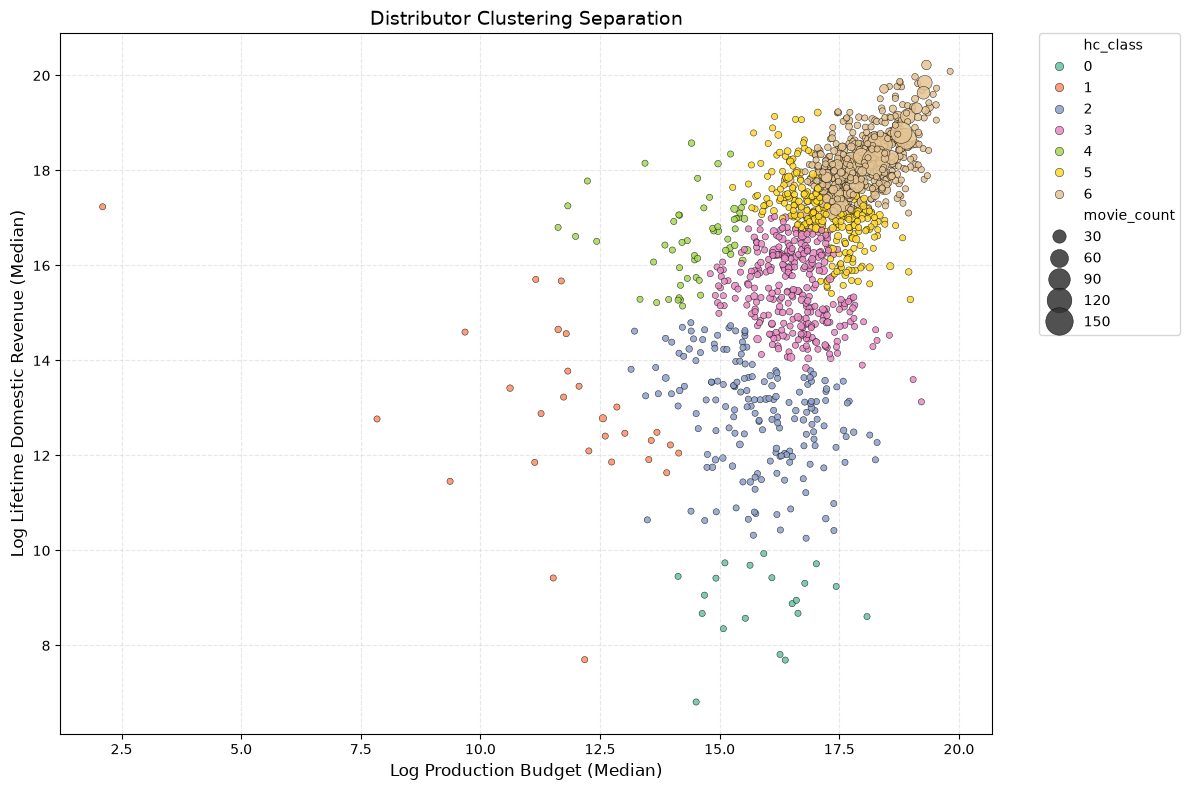

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size
plt.figure(figsize=(12, 8))

# Create the scatter plot
# x/y: The main separation features
# hue: The cluster assignment
# size: The number of movies released (log_count)
sns.scatterplot(
    data=data_to_cluster,
    x='production_budget_adj_log',
    y='bom_dom_lifetime_adj_log',
    hue='hc_class',
    size='movie_count',
    sizes=(20, 400),       # Range of bubble sizes
    palette='Set2',     # distinct colors
    alpha=0.85,             # transparency to see overlaps
    edgecolor='black'
)

# Improve labels and title
plt.title('Distributor Clustering Separation', fontsize=14)
plt.xlabel('Log Production Budget (Median)', fontsize=12)
plt.ylabel('Log Lifetime Domestic Revenue (Median)', fontsize=12)

# Move legend outside so it doesn't block data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Optional: Annotate the "Big" distributors to confirm your theory about Class 5
# This loops through the top 10 distributors by movie count and writes their names on the chart

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Seasonality Cluster Map

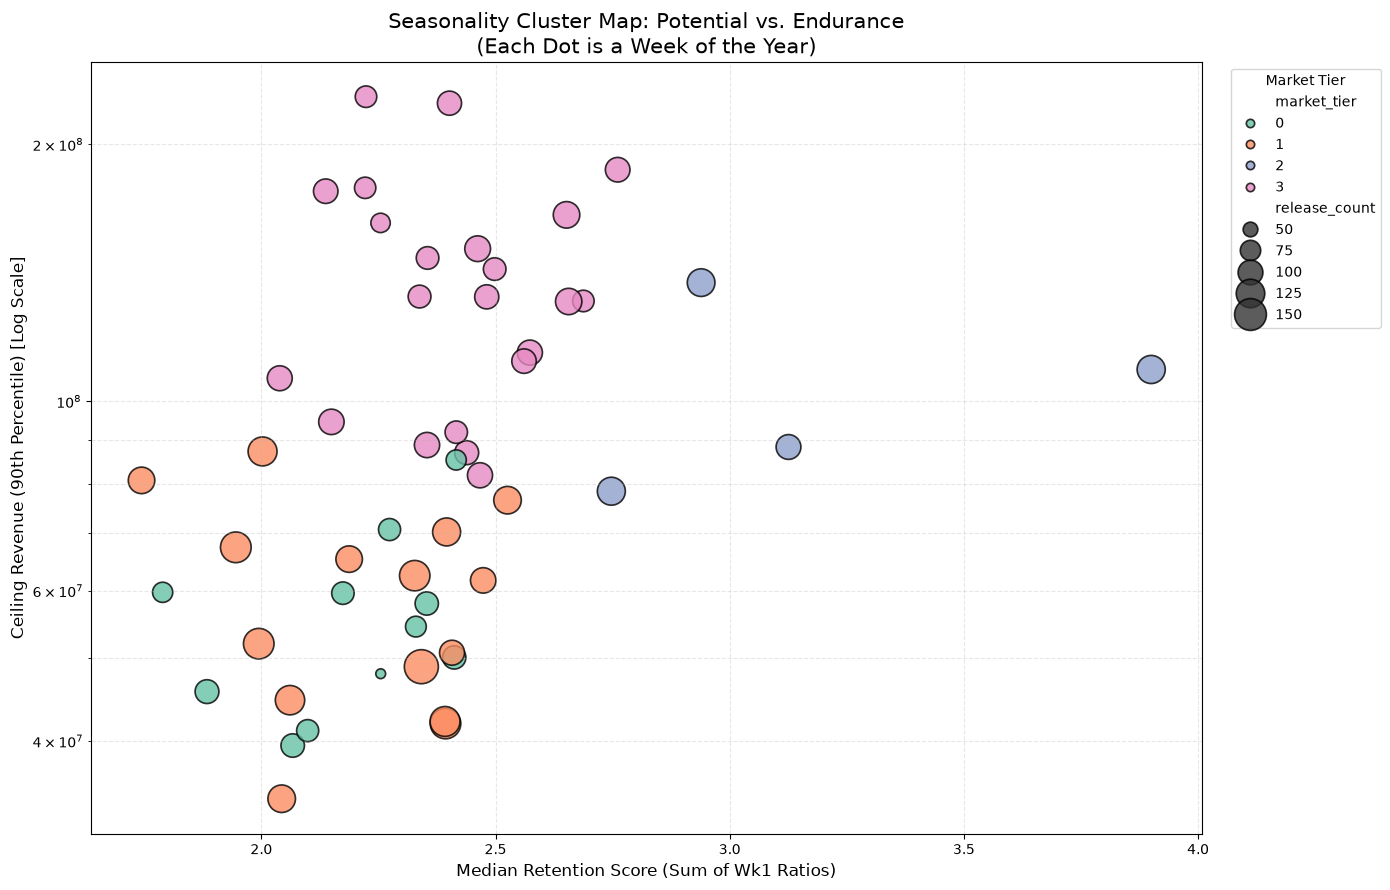

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the index (Week Number) is a column for plotting/labeling
plot_data = bucket_stats.reset_index()

plt.figure(figsize=(14, 9))

# --- MAIN SCATTER PLOT ---
# X-Axis: Endurance (How well movies hold)
# Y-Axis: Potential (How high movies fly)
# Size: Crowding (How many movies release)
sns.scatterplot(
    data=plot_data,
    x='median_retention',
    y='ceiling_rev',
    hue='market_tier',
    size='release_count',
    sizes=(50, 600),
    palette='Set2',  # 0=Purple (Weak), 3=Yellow (Strong)
    alpha=0.8,
    edgecolor='black'
)

# --- FORMATTING ---
plt.yscale('log')  # Log scale for revenue to see the tiers clearly
plt.title('Seasonality Cluster Map: Potential vs. Endurance\n(Each Dot is a Week of the Year)', fontsize=15)
plt.ylabel('Ceiling Revenue (90th Percentile) [Log Scale]', fontsize=12)
plt.xlabel('Median Retention Score (Sum of Wk1 Ratios)', fontsize=12)

plt.grid(True, which="both", ls="--", alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Market Tier")
plt.tight_layout()
plt.show()

Movie hype tier analysis from wiki views

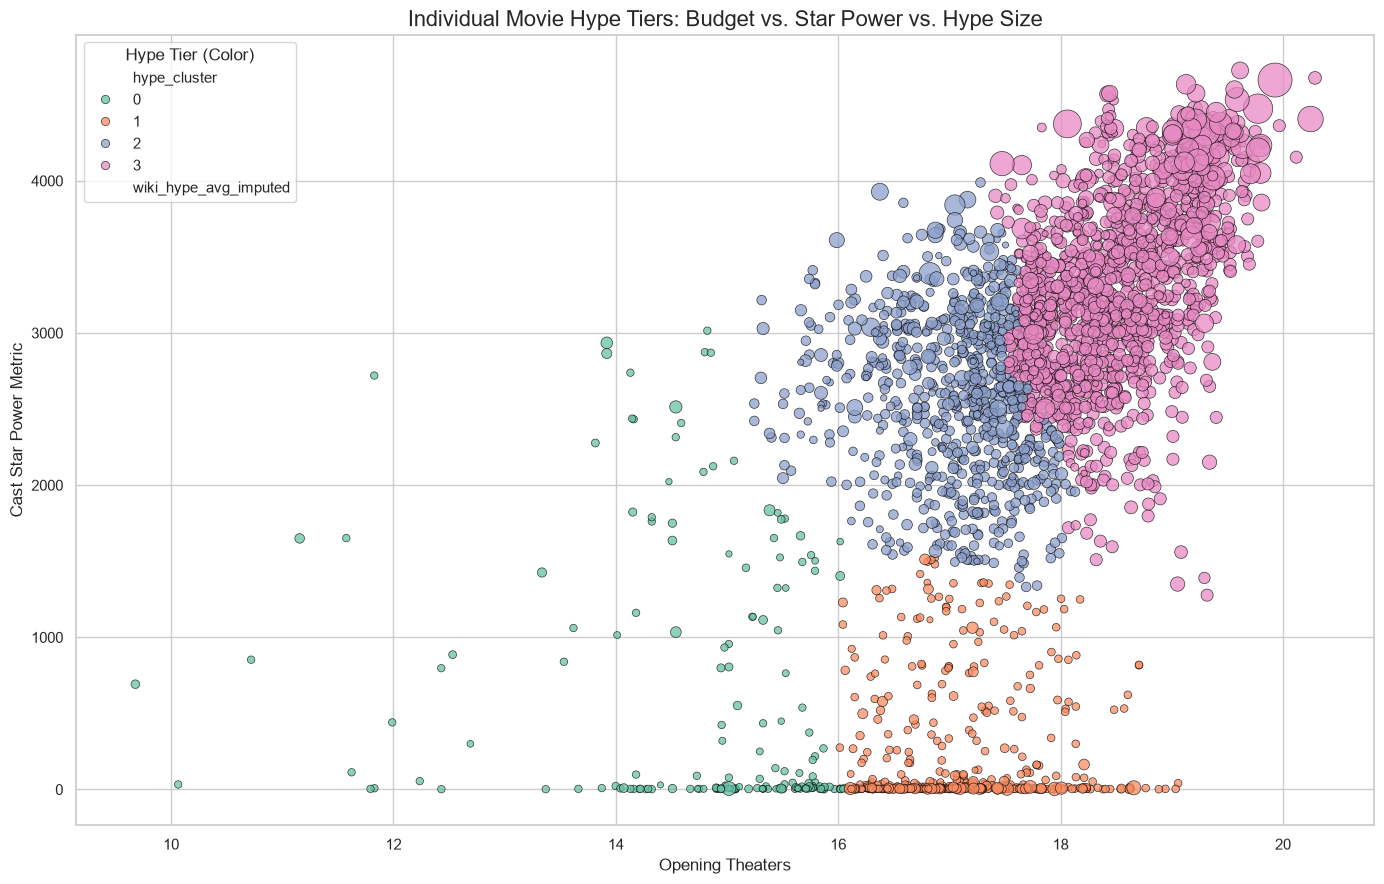

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set(style="whitegrid")
plt.figure(figsize=(14, 9))

# --- THE PLOT ---
# We use a smaller range for sizes ((20, 400)) compared to the summary chart,
# otherwise overlapping big bubbles make the plot unreadable.
scatter = sns.scatterplot(
    data=dataset_refined,
    x='production_budget_adj_log',  # Dimension 1: Money
    y='opening_theaters',            # Dimension 2: Stars
    hue='hype_cluster',             # Color: The Tier (0-4)
    size='wiki_hype_avg_imputed',       # Bubble Size: The resulting Hype
    palette='Set2',              # Sequential color scheme (0=purple, 4=yellow)
    sizes=(20, 600),                # Map min/max hype to min/max bubble area
    alpha=0.75,                      # Transparency is CRITICAL here
    edgecolor='black',                  # White edges help distinguish overlapping bubbles
    linewidth=0.5,
)

# --- FORMATTING & CLEANING LEGEND ---
plt.title('Individual Movie Hype Tiers: Budget vs. Star Power vs. Hype Size', fontsize=16)
plt.xlabel('Opening Theaters', fontsize=12)
plt.ylabel('Cast Star Power Metric', fontsize=12)

# The default legend includes both color (tiers) and sizes (hype numbers).
# It gets very messy. Let's clean it up to show mostly just the tiers.
h, l = scatter.get_legend_handles_labels()
# Generally, the first few entries are the colors (hue), followed by sizes.
# Adjust the slicing [:6] if your legend looks weird.
plt.legend(h[:6], l[:6], title="Hype Tier (Color)", loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

Decay Physics

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mahmu\AppData\Local\Temp\ipykernel_25868\716382457.py:22: SyntaxWarning: invalid escape sequence '\d'
  plot_data['Day_Num'] = plot_data['Day'].str.extract('(\d+)').astype(int)


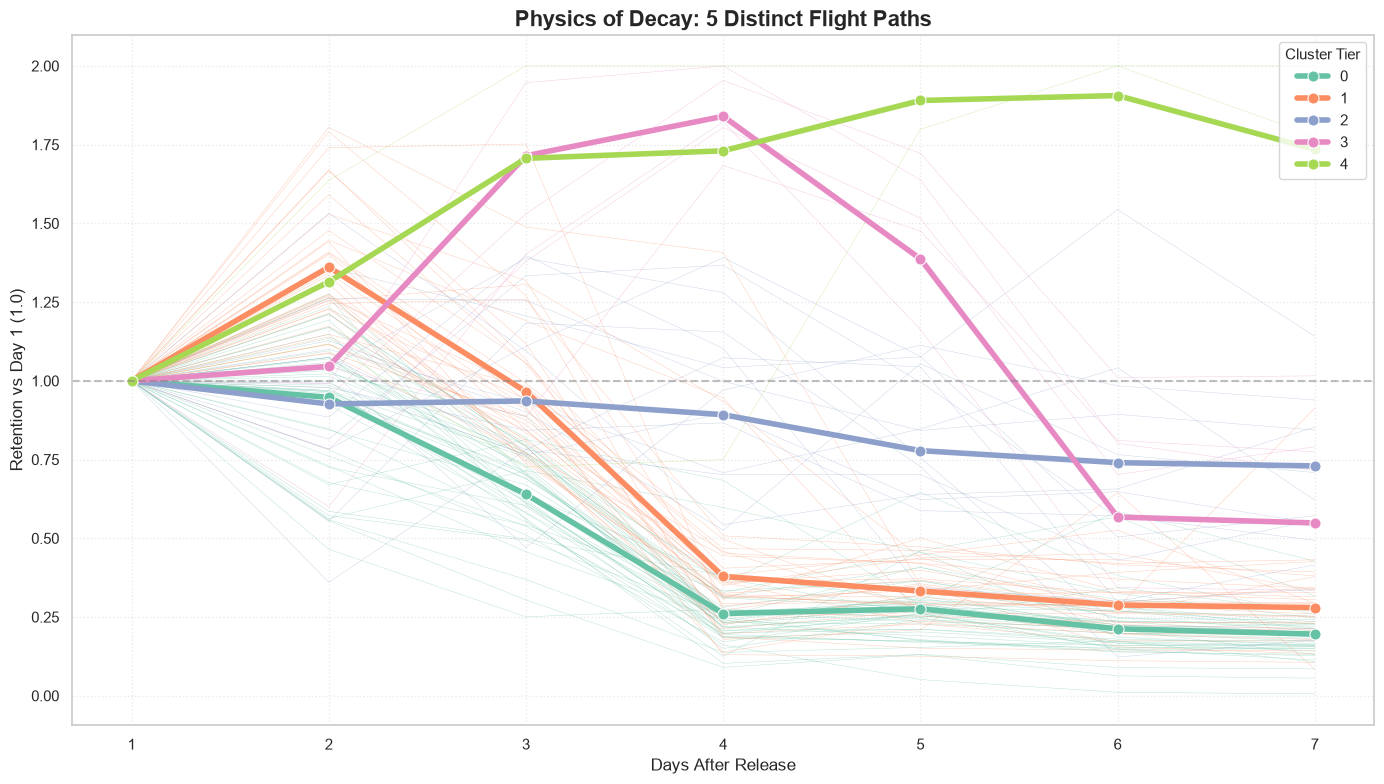

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- STEP 1: PREPARE DATA ---
# We need 'tmdb_id' (or your movie ID) to track individual units.
# We also include Day 1 (fixed at 1.0) for a complete curve.
viz_subset = clustering_subset.copy()
viz_subset['ratio_day_1'] = 1.0

# Organize columns for the melt
day_cols = [f'ratio_day_{i}' for i in range(1, 8)]

# MELT: Convert to long format for Seaborn
plot_data = viz_subset.melt(
    id_vars=[ID_COL, 'decay_cluster'], # ID_COL = 'tmdb_id'
    value_vars=day_cols,
    var_name='Day',
    value_name='Retention Ratio'
)

# Clean up 'Day' column to be numeric (1, 2, ... 7) for proper x-axis spacing
plot_data['Day_Num'] = plot_data['Day'].str.extract('(\d+)').astype(int)

# --- STEP 2: SAMPLING FOR BACKGROUND (The Thin Lines) ---
# We sample ~200 unique movies to keep the visual clean.
# If we plot all 5,000+ movies, it will just look like a solid block of color.
sample_ids = viz_subset.sample(n=min(100, len(viz_subset)), random_state=42)[ID_COL]
background_data = plot_data[plot_data[ID_COL].isin(sample_ids)]

# --- STEP 3: PLOTTING ---
plt.figure(figsize=(14, 8))

# Define Palette (Red=Burn, Blue=Legs)
palette_name = 'Set2'

# LAYER 1: The "Ghost" Lines (Individual Movies)
# units=ID_COL tells seaborn to draw one line per movie
sns.lineplot(
    data=background_data,
    x='Day_Num',
    y='Retention Ratio',
    hue='decay_cluster',
    palette=palette_name,
    units=ID_COL,       # IMPORTANT: This separates the lines!
    estimator=None,     # IMPORTANT: Don't aggregate, show raw data
    lw=0.3,             # Very thin
    alpha=0.5,         # Very transparent
    legend=None,        # No legend for background noise
    zorder=1
)

# LAYER 2: The "Archetype" Lines (Cluster Averages)
# We use the FULL plot_data here to get the true mathematical average
sns.lineplot(
    data=plot_data,
    x='Day_Num',
    y='Retention Ratio',
    hue='decay_cluster',
    palette=palette_name,
    errorbar=None,      # Turn off confidence intervals for cleaner look
    lw=4,               # Thick lines
    marker='o',         # Dots at data points
    markersize=8,
    zorder=2
)

# --- FORMATTING ---
plt.title('Physics of Decay: 5 Distinct Flight Paths', fontsize=16, fontweight='bold')
plt.ylabel('Retention vs Day 1 (1.0)', fontsize=12)
plt.xlabel('Days After Release', fontsize=12)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xticks(range(1, 8))

# Legend cleanup
plt.legend(title='Cluster Tier', title_fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

Seasonality

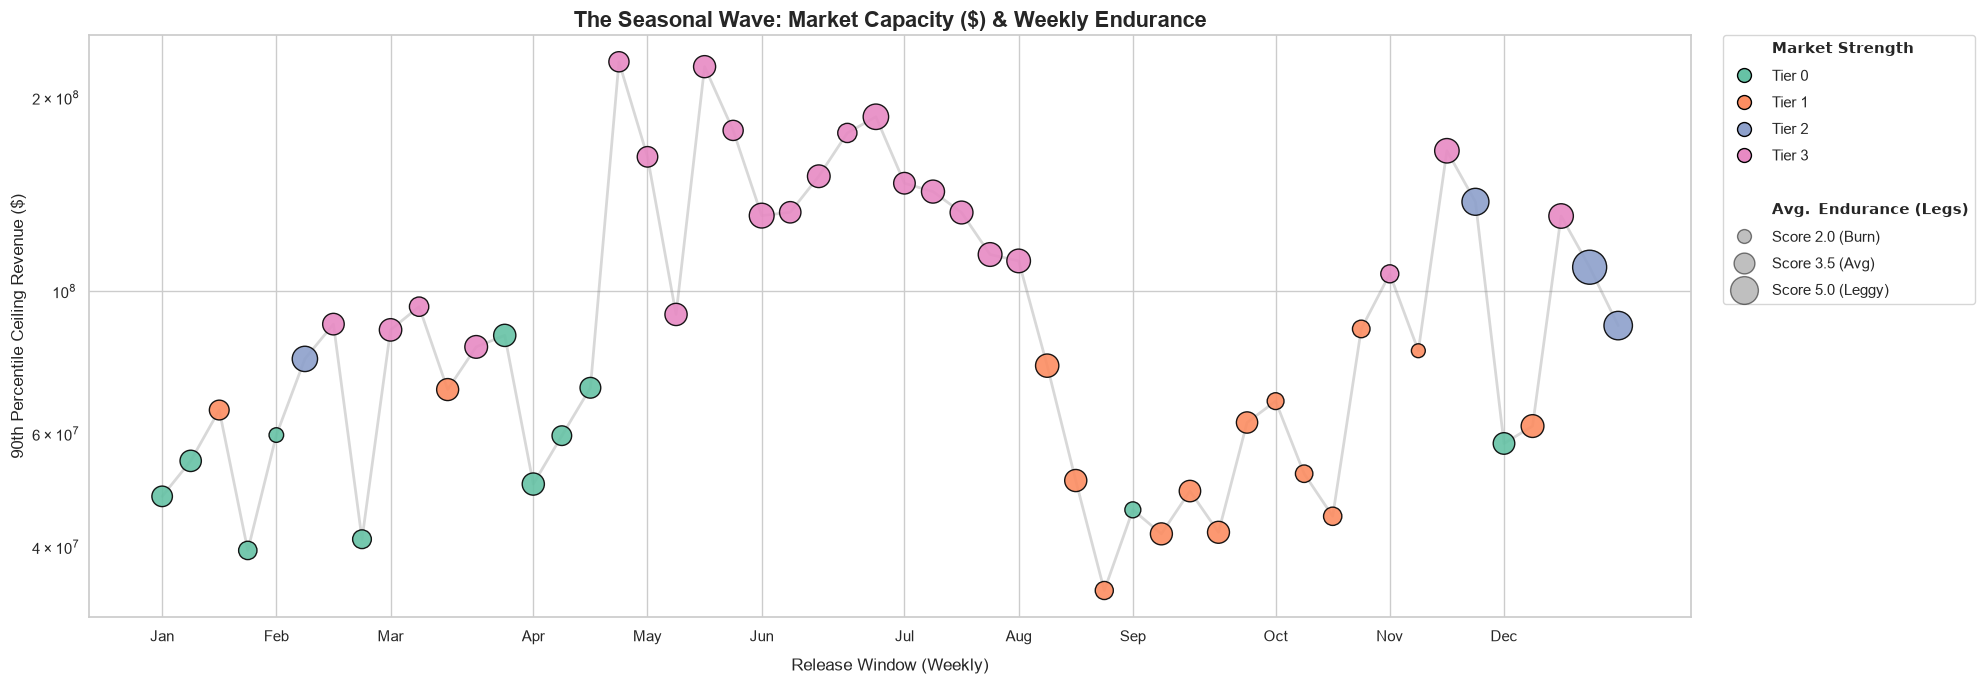

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns


# 1. PREP: Ensure data is sorted by week so the line connects properly
bucket_stats = bucket_stats.sort_index()

# 2. SETUP: Figure & Style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 7))

# --- LAYER 1: The Trend Line (Capacity) ---
# Draws a faint line connecting the weeks to show the "Wave" shape
sns.lineplot(
    data=bucket_stats,
    x=bucket_stats.index,
    y='ceiling_rev',
    color='gray',
    alpha=0.3,
    linewidth=2,
    zorder=1
)

# --- LAYER 2: The Clusters (Bubbles) ---
# Hue = Market Tier (Strength), Size = Retention (Legs)
ax = sns.scatterplot(
    data=bucket_stats,
    x=bucket_stats.index,
    y='ceiling_rev',
    hue='market_tier',
    size='median_retention',
    sizes=(100, 600),       # Adjust bubble size range
    palette='Set2',      # distinct colors
    alpha=0.9,
    edgecolor='black',
    linewidth=1,
    zorder=2
)

# --- LAYER 3: CLEAN TICKS (The "Neatness" Priority) ---
# Instead of 1-52, we label the approximate start of each month
month_ticks = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.xticks(month_ticks, month_labels, fontsize=11, rotation=0)
plt.xlabel('Release Window (Weekly)', fontsize=12, labelpad=10)

# Y-Axis formatting
plt.yscale('log') # Log scale reveals the structure of lower tiers
plt.ylabel('90th Percentile Ceiling Revenue ($)', fontsize=12)
plt.title('The Seasonal Wave: Market Capacity ($) & Weekly Endurance', fontsize=16, weight='bold')

# --- LAYER 4: CUSTOM LEGEND ---
# We build a custom legend to separate "Tier" from "Legs" cleanly

# A. Create handles for the Market Tiers (Colors)
# Assuming 4 tiers (0-3). We grab colors from the 'viridis' palette used above.
unique_tiers = sorted(bucket_stats['market_tier'].unique())
palette = sns.color_palette('Set2', n_colors=len(unique_tiers))
tier_handles = []
for i, tier in enumerate(unique_tiers):
    tier_handles.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=palette[i],
               markersize=10, markeredgecolor='black', label=f'Tier {tier}')
    )

# B. Create handles for Endurance (Sizes)
# Based on typical retention scores (Burn=2.0, Avg=3.5, Leggy=5.0)
size_handles = [
    Line2D([0], [0], marker='o', color='w', label='Score 2.0 (Burn)',
           markerfacecolor='gray', markersize=10, markeredgecolor='black', alpha=0.5),
    Line2D([0], [0], marker='o', color='w', label='Score 3.5 (Avg)',
           markerfacecolor='gray', markersize=15, markeredgecolor='black', alpha=0.5),
    Line2D([0], [0], marker='o', color='w', label='Score 5.0 (Leggy)',
           markerfacecolor='gray', markersize=20, markeredgecolor='black', alpha=0.5)
]

# C. Create Headers/Spacers
header_tier = Line2D([0], [0], color='none', label=r'$\bf{Market\ Strength}$')
header_legs = Line2D([0], [0], color='none', label=r'$\bf{Avg.\ Endurance\ (Legs)}$')
spacer = Line2D([0], [0], color='none', label='')

# D. Combine & Plot
final_handles = [header_tier] + tier_handles + [spacer, header_legs] + size_handles

ax.legend(
    handles=final_handles,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=0.,
    frameon=True,
    labelspacing=0.8
)

plt.tight_layout()
plt.show()

Silhouette score was used to get a hint at the ideal number of k for Wikipedia hype clustering.

Calculating Silhouette Scores (this may take a moment)...


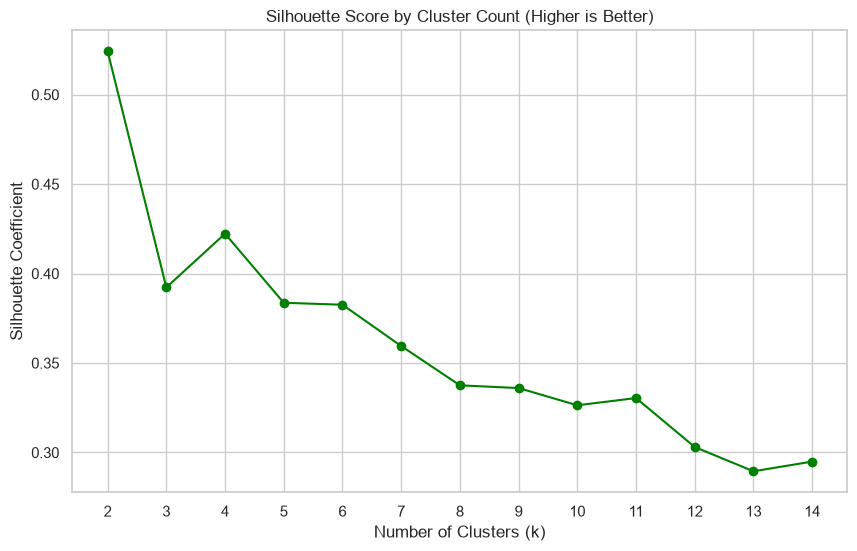

In [91]:
# Define range (Silhouette Score requires at least 2 clusters)
K_range = range(2, 15)
sil_scores = []

print("Calculating Silhouette Scores (this may take a moment)...")

for k in K_range:
    # Use AgglomerativeClustering to match your final model strategy
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(X_scaled)

    # Calculate the score for this k
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

# --- PLOT THE GRAPH ---
plt.figure(figsize=(10, 6))
plt.plot(K_range, sil_scores, marker='o', linestyle='-', color='green')

plt.title('Silhouette Score by Cluster Count (Higher is Better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Coefficient')
plt.xticks(K_range)
plt.grid(True)

plt.show()

Momentum Graph

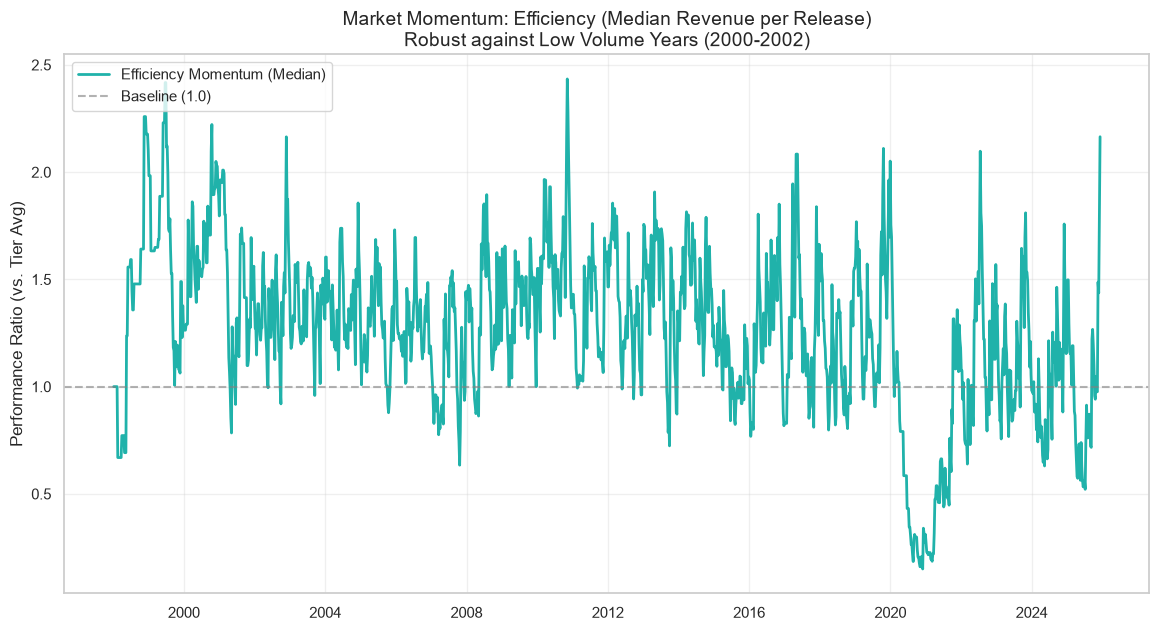

              weekly_median_revenue  tier  market_momentum_lagged
release_date                                                     
2025-11-10               53304860.0     0                0.976045
2025-11-17               24478611.5     1                1.487340
2025-11-24              207468280.0     3                1.436795
2025-12-01              169876630.0     0                1.831134
2025-12-08               71050025.0     1                2.164806


In [92]:
# --- STEP 5: VISUALIZE ---
plt.figure(figsize=(14, 7))
plt.plot(weekly_market.index, weekly_market['market_momentum_lagged'], color='lightseagreen', linewidth=2, label='Efficiency Momentum (Median)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.6, label='Baseline (1.0)')

plt.title('Market Momentum: Efficiency (Median Revenue per Release)\nRobust against Low Volume Years (2000-2002)', fontsize=14)
plt.ylabel('Performance Ratio (vs. Tier Avg)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Snapshot
print(weekly_market[['weekly_median_revenue', 'tier', 'market_momentum_lagged']].tail())

Elbow method graph

Calculating inertia for different k values...


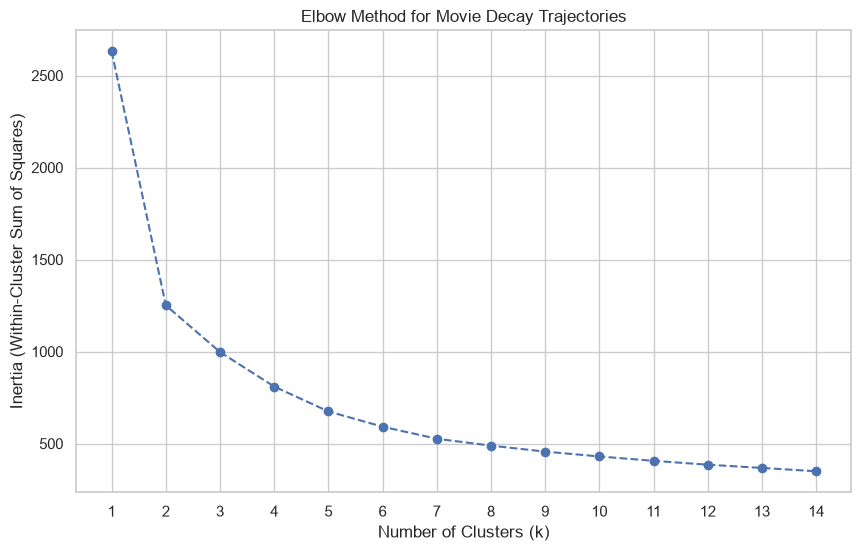

In [93]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Define the range of clusters you want to test (e.g., 1 to 15)
K_range = range(1, 15)
inertias = []

# --- CALCULATE INERTIA FOR EACH K ---
print("Calculating inertia for different k values...")
for k in K_range:
    # We use n_init=10 here for speed during the search phase
    # You can increase it to 50 later for the final model
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clustering_subset[ratio_cols])
    inertias.append(km.inertia_)

# --- PLOT THE GRAPH ---
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')

# Formatting for readability
plt.title('Elbow Method for Movie Decay Trajectories')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)

plt.show()